# Audio -> MIDI + End-to-End Joint CVAE + PPO (Colab)

## Pipeline Ozeti

```
ADIM 1  [Drive Setup]     recordings.zip -> /content/raw_recordings
ADIM 2  [Kurulum]         Cell 1: Paketler | Cell 1b: Opsiyonel
ADIM 3  [Konfigürasyon]   Cell 2: ROOT, CFG, DEVICE, SEED
ADIM 4  [Modeller]        Cell 3-6: Yardimcilar, tokenizer, CVAE, JointTrainer
ADIM 5  [Ses + Veri]      Cell 7: Ses yukle + MAESTRO indir + Basic Pitch
ADIM 6  [Analiz]          Cell 8: Akor, key, mood cikar
ADIM 7  [CVAE Egitimi]    Cell 9: MAESTRO uzerinde CVAE pretraining
ADIM 8  [Kullanici FT]    Cell A1-A3: Kendi ses kayitlarinla CVAE domain adaptation
ADIM 9  [RL Verisi]       Cell A4-A5: Pseudo-pair + RL veri secici
ADIM 10 [Joint RL]        Cell 10-12: Seed bank + Trainer init + Training loop
ADIM 11 [Cikti]           Cell 13-15: Variant uret + Degerlendir + Kaydet
```

**Not:** ADIM 1 (Drive Setup) istege baglidir. Drive yoksa sentetik ses veya
tek dosya upload ile devam edilir.


## ADIM 1: Drive Setup -- Ses Kayitlarini Yukle

> **Bu bolum istege baglidir.** Google Drive'inizda
> `Colab Notebooks/thesis_audio/recordings.zip` varsa asagidaki
> 3 hucreyi sirasyla calistirin. Yoksa bu bolumu atlayin.

> **Arsiv yolu:** `/content/drive/MyDrive/Colab Notebooks/thesis_audio/recordings.zip`

> **Icerik:** Kendi vokal ve gitar WAV/M4A/MP3 kayitlariniz

> **Bu bolum su klasoru olusturur:** `/content/raw_recordings/`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

src = '/content/drive/MyDrive/Colab Notebooks/thesis_audio/recordings.zip'
dst = '/content/recordings.zip'
shutil.copy(src, dst)

print('Copied to:', dst)

Copied to: /content/recordings.zip


In [ ]:
import os, shutil, zipfile

zip_path = '/content/drive/MyDrive/Colab Notebooks/thesis_audio/recordings.zip'
local_zip = '/content/recordings.zip'
extract_dir = '/content/raw_recordings'

shutil.copy(zip_path, local_zip)
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(local_zip, 'r') as z:
    z.extractall(extract_dir)

print('Extracted to:', extract_dir)

Extracted to: /content/raw_recordings


## ADIM 2: Paket Kurulumu

> Once **Cell 1** (zorunlu paketler), sonra **Cell 1b** (OpenUnmix, musdb -- istege bagli).
> Cell 1b atlanirsa pseudo-pair ozelligi devre disi kalir.


In [ ]:
# Cell 1 – Install dependencies (Colab-safe, minimal, robust)
# ─────────────────────────────────────────────────────────────────────────────
# REQUIRES: Colab Runtime Version 2025.07 (Python 3.11)
#   Runtime → Change runtime type → Runtime Version 2025.07
# ─────────────────────────────────────────────────────────────────────────────
import json, os, sys, shutil, traceback, subprocess, importlib, importlib.util
try:
    import importlib.metadata as importlib_metadata
except Exception:
    import importlib_metadata

SENTINEL = "/content/.joint_e2e_env_ready_v6.json"

# ── Packages that must never be touched by this notebook ──────────────────────
PROTECTED_DISTS = [
    "google-colab", "ipython", "ipykernel", "jupyter", "jupyter-client",
    "jupyter-core", "notebook", "nbclassic", "traitlets", "prompt-toolkit",
    "pygments", "tornado", "pyzmq",
]

RECOVERY = (
    "Recovery steps:\n"
    "1) Runtime → Disconnect and delete runtime\n"
    "2) Reopen notebook\n"
    "3) Runtime → Change runtime type → Runtime Version 2025.07 (Python 3.11)\n"
    "4) Re-run from Cell 1"
)
IN_COLAB = importlib.util.find_spec("google.colab") is not None

def fail_setup(msg):
    raise RuntimeError(f"{msg}\n\n{RECOVERY}")

def run_pip(*args):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--no-input",
           "--disable-pip-version-check", "--no-warn-script-location",
           "--upgrade-strategy", "only-if-needed"] + list(args)
    print("[pip]", " ".join(str(a) for a in args))
    r = subprocess.run(cmd, text=True, capture_output=True)
    if r.returncode != 0:
        tail = (r.stderr or "").strip()[-1500:]
        print("[pip][stderr]", tail)
    return r

def has_module(name):
    return importlib.util.find_spec(name) is not None

def dist_ver(name):
    try:
        return importlib_metadata.version(name)
    except Exception:
        return None

# ── 1. Python version guard ────────────────────────────────────────────────────
print(f"Python {sys.version.split()[0]}")
py_maj, py_min = sys.version_info[:2]
if py_maj == 3 and py_min >= 12:
    fail_setup(
        f"Python {py_maj}.{py_min} detected.\n"
        "basic-pitch requires Python ≤ 3.11.\n"
        "Switch to Runtime Version 2025.07 (Python 3.11)."
    )

# ── 2. Snapshot protected packages before any installs ────────────────────────
snap_before = {d: dist_ver(d) for d in PROTECTED_DISTS}

# ── 3. Core installs (only what the main notebook path truly needs) ───────────
# Install order matters: librosa before basic-pitch so resampy resolution is sane.
CORE_STEPS = [
    # (import_name, pip_args)
    ("pretty_midi",  ["pretty_midi"]),
    ("music21",      ["music21"]),
    ("librosa",      ["librosa==0.10.2.post1"]),
    ("soundfile",    ["soundfile"]),
    ("mir_eval",     ["mir_eval"]),
    # basic-pitch 0.4.0 is installed --no-deps to avoid pulling a conflicting
    # tensorflow/numpy combo.  We then install its missing direct deps explicitly.
    ("basic_pitch",  ["--no-deps", "basic-pitch==0.4.0"]),
    # resampy is a direct dep of basic-pitch not pulled by --no-deps
    ("resampy",      ["resampy>=0.4.2"]),
]

sentinel_ok = os.path.exists(SENTINEL)
# Quick import probe for core packages
CORE_IMPORTS = ["basic_pitch", "pretty_midi", "librosa", "music21",
                "soundfile", "mir_eval", "resampy"]
missing_core = [m for m in CORE_IMPORTS if not has_module(m)]

if sentinel_ok and not missing_core:
    print("Sentinel present and all core imports healthy — skipping pip install.")
else:
    if sentinel_ok:
        print(f"Sentinel present but {len(missing_core)} import(s) missing; re-running installs.")
    for import_name, pip_args in CORE_STEPS:
        if not has_module(import_name):
            r = run_pip(*pip_args)
            if r.returncode != 0:
                fail_setup(f"Failed to install {import_name}.\nPip output:\n{(r.stderr or '')[-800:]}")
        else:
            print(f"[skip] {import_name} already importable")

    # System audio packages (best-effort, non-fatal)
    if IN_COLAB and shutil.which("apt-get"):
        print("Installing system audio packages (best effort)…")
        subprocess.run(
            ["apt-get", "install", "-y", "-qq", "fluidsynth", "fluid-soundfont-gm"],
            text=True, capture_output=True
        )

# ── 4. Protected package guard ────────────────────────────────────────────────
importlib.invalidate_caches()
snap_after = {d: dist_ver(d) for d in PROTECTED_DISTS}
changed = {d: (snap_before[d], snap_after[d])
           for d in PROTECTED_DISTS if snap_before[d] != snap_after[d]}
if changed:
    fail_setup(
        "Protected Colab shell packages were mutated:\n"
        + json.dumps(changed, indent=2)
    )

# ── 5. Final import verification (core only) ──────────────────────────────────
failures = {}
for m in CORE_IMPORTS:
    try:
        importlib.import_module(m)
    except Exception as exc:
        failures[m] = f"{type(exc).__name__}: {exc}"

if failures:
    fail_setup(
        "Core imports still failing after install:\n"
        + "\n".join(f"  {k}: {v}" for k, v in failures.items())
    )

# ── 6. Write sentinel ─────────────────────────────────────────────────────────
with open(SENTINEL, "w") as fh:
    json.dump({"python": sys.version.split()[0],
               "core_ok": list(CORE_IMPORTS),
               "protected": snap_after}, fh, indent=2)

print("\nCell 1 complete. Core environment ready.")
print("Optional features (openunmix / musdb / stempeg) are installed in Cell 1b below.")
print("Proceed to Cell 1b (optional) or Cell 2.")


Python 3.11.13
[pip] pretty_midi
[skip] music21 already importable
[skip] librosa already importable
[skip] soundfile already importable
[pip] mir_eval
[pip] --no-deps basic-pitch==0.4.0
[pip] resampy>=0.4.2
Installing system audio packages (best effort)…



Cell 1 complete. Core environment ready.
Optional features (openunmix / musdb / stempeg) are installed in Cell 1b below.
Proceed to Cell 1b (optional) or Cell 2.


In [ ]:
# Cell 1b – Optional feature installs (pseudo-pair source separation)
# ─────────────────────────────────────────────────────────────────────────────
# Safe to skip if you do not need pseudo-pair generation (pseudo_pair_enable=False).
# These packages are NOT required for the core MAESTRO → CVAE → RL path.
# Run this cell only if you want to use Open-Unmix source separation.
# ─────────────────────────────────────────────────────────────────────────────
import importlib, subprocess, sys

OPTIONAL = [
    ("openunmix", ["openunmix"]),
    ("musdb",     ["musdb"]),
    ("stempeg",   ["stempeg"]),
]

def run_pip_opt(*args):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--no-input",
           "--disable-pip-version-check", "--no-warn-script-location",
           "--upgrade-strategy", "only-if-needed"] + list(args)
    print("[pip-opt]", " ".join(str(a) for a in args))
    r = subprocess.run(cmd, text=True, capture_output=True)
    if r.returncode != 0:
        print(f"[pip-opt][warn] Install failed (non-fatal): {(r.stderr or '')[-400:]}")
    return r.returncode == 0

report = {}
for import_name, pip_args in OPTIONAL:
    if importlib.util.find_spec(import_name):
        print(f"[skip] {import_name} already present")
        report[import_name] = "already_present"
    else:
        ok = run_pip_opt(*pip_args)
        importlib.invalidate_caches()
        importlib.util.find_spec.cache_clear() if hasattr(importlib.util.find_spec, "cache_clear") else None
        available = importlib.util.find_spec(import_name) is not None
        report[import_name] = "ok" if (ok and available) else "FAILED (non-fatal)"

print("\nOptional package status:")
for k, v in report.items():
    print(f"  {k}: {v}")
# -- pseudo-pair erisebilirligi: Cell 2 bu flag i okuyacak --
_PSEUDO_PAIR_DEPS_OK = all(v in ("ok", "already_present") for v in report.values())

print("\nCell 1b complete.")
if _PSEUDO_PAIR_DEPS_OK:
    print("  All optional packages available -- pseudo-pair generation enabled.")
else:
    _failed_pkgs = [k for k, v in report.items() if v not in ("ok", "already_present")]
    print(f"  Missing packages: {_failed_pkgs}")
    print("  pseudo_pair_enable will be set to False automatically in Cell 2.")


[pip-opt] openunmix
[pip-opt] musdb
[skip] stempeg already present

Optional package status:
  openunmix: ok
  musdb: ok
  stempeg: already_present

Cell 1b complete.
  All optional packages available -- pseudo-pair generation enabled.


## ADIM 3-4: Konfigürasyon ve Model Tanimlari

> **Cell 2:** ROOT, CFG, DEVICE, SEED tanimlanir -- her seyin temeli.
> **Cell 3-6:** Yardimci fonksiyonlar, tokenizer, dataset ve model siniflarini yazar.
> Bu hucreleri calistirmadan hicbir sey calisir.


In [ ]:
# Cell 2 - Setup, seed, config
import os, sys, json, math, random, zipfile, shutil, urllib.request
from pathlib import Path

import numpy as np
import torch

ROOT = "/content/thesis_joint_e2e"
OUT_DIR = ROOT + "/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

CFG = dict(
    # token / CVAE
    vocab=177,
    emb_dim=48,
    hidden=128,
    latent_dim=32,
    n_moods=3,
    seq_len=129,
    batch=32,
    cvae_epochs=20,
    cvae_lr=2e-3,
    beta_kl_warmup=2000,
    # conditioning
    n_chord_classes=25,
    chord_emb_dim=12,
    n_bar_bins=8,
    bar_emb_dim=8,
    use_chord_cond=True,
    use_bar_cond=True,
    # mel / render
    sr=16000,
    n_fft=1024,
    hop_length=256,
    mel_bins=80,
    T_win=32,
    render_max_sec=2.0,
    max_synth_notes=48,
    # RL / joint training
    dataset_mode="hybrid",
    musdb_max_songs=12,
    iddm_steps=50,
    n_rollout=8,
    enc_dim=96,
    lr_joint=2e-4,
    lr_disc=8e-4,
    lr_mine=8e-4,
    lambda_entropy=1e-3,
    lambda_mi=1e-2,
    clip_eps=0.2,
    gamma=0.99,
    lam_gae=0.95,
    value_coef=0.5,
    supervised_anchor_coef=0.15,
    decoder_logprob_coef=1.0,
    token_entropy_coef=1e-4,
    latent_residual_scale_init=0.10,
    rl_temperature=0.95,
    # PATCH: user-recording fine-tuning config uses one consistent naming scheme.
    use_user_finetune=True,
    user_ft_audio_dir="/content/raw_recordings",
    user_ft_segment_sec=15.0,
    user_ft_overlap_sec=2.0,
    user_ft_min_voiced_sec=3.0,
    user_ft_max_silence_ratio=0.60,
    user_ft_long_silence_sec=7.0,
    user_ft_silence_db_thresh=-50.0,
    user_ft_trim_long_silence=True,
    user_ft_lr=3e-4,
    user_ft_epochs=5,
    user_ft_batch=16,
    user_ft_min_notes=8,
    user_ft_min_duration=2.0,
    # PATCH: pseudo-pair / RL dataset priority and MUSDB preview smoke-test controls.
    pseudo_pair_enable=True,
    # Kendi ses kayitlarin (Cell 18 sonrasi wav/mp3 formatinda hazirlanir)
    # Cell 18 (hazirlik hucresi) calistiktan SONRA bu klasor dolu olur
    pseudo_pair_audio_dir="/content/user_ft_input_audio",
    pseudo_pair_cache_dir="/content/thesis_joint_e2e/pseudo_pairs",
    use_musdb_preview=True,          # MUSDB 7-sec excerpt download icin True
    musdb_preview_max_tracks=7,       # kac excerpt track kullanilacak (7 sec x track)
    rl_dataset_priority="auto",
)
# -- Cell 1b den gelen pseudo-pair bagimlilik sonucunu uygula --
if not globals().get("_PSEUDO_PAIR_DEPS_OK", True):
    CFG["pseudo_pair_enable"] = False
    print("[CFG] pseudo_pair_enable -> False  (Cell 1b bagimlilik eksik)")

print(json.dumps(CFG, indent=2))


DEVICE: cuda
{
  "vocab": 177,
  "emb_dim": 48,
  "hidden": 128,
  "latent_dim": 32,
  "n_moods": 3,
  "seq_len": 129,
  "batch": 32,
  "cvae_epochs": 20,
  "cvae_lr": 0.002,
  "beta_kl_warmup": 2000,
  "n_chord_classes": 25,
  "chord_emb_dim": 12,
  "n_bar_bins": 8,
  "bar_emb_dim": 8,
  "use_chord_cond": true,
  "use_bar_cond": true,
  "sr": 16000,
  "n_fft": 1024,
  "hop_length": 256,
  "mel_bins": 80,
  "T_win": 32,
  "render_max_sec": 2.0,
  "max_synth_notes": 48,
  "dataset_mode": "hybrid",
  "musdb_max_songs": 12,
  "iddm_steps": 120,
  "n_rollout": 8,
  "enc_dim": 96,
  "lr_joint": 0.0002,
  "lr_disc": 0.0008,
  "lr_mine": 0.0008,
  "lambda_entropy": 0.001,
  "lambda_mi": 0.01,
  "clip_eps": 0.2,
  "gamma": 0.99,
  "lam_gae": 0.95,
  "value_coef": 0.5,
  "supervised_anchor_coef": 0.15,
  "decoder_logprob_coef": 1.0,
  "token_entropy_coef": 0.0001,
  "latent_residual_scale_init": 0.1,
  "rl_temperature": 0.95,
  "use_user_finetune": true,
  "user_ft_audio_dir": "/content/raw_rec

In [ ]:
# Cell 3 - Core helpers, tokenisation, conditioning heuristics
import bisect
import importlib
from tqdm.auto import tqdm

def ensure_import(module_name, pip_name=None):
    try:
        return importlib.import_module(module_name)
    except ModuleNotFoundError as exc:
        pkg = pip_name or module_name
        raise RuntimeError(
            f"Missing package '{pkg}'. Run Cell 1 first or repair the setup environment."
        ) from exc

pretty_midi = ensure_import("pretty_midi", "pretty_midi")
m21 = ensure_import("music21", "music21")
librosa = ensure_import("librosa", "librosa==0.10.2.post1")
sf = ensure_import("soundfile", "soundfile")

import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

PITCH_OFFSET=0
DUR_OFFSET=128
TEMPO_OFFSET=160
PAD_TOKEN=176
VOCAB_SIZE=177
DUR_BINS=[0.0625,0.125,0.1875,0.25,0.375,0.5,0.75,1.0,1.5,2.0,3.0,4.0]
TEMPO_BINS=list(range(40,205,10))
MOOD_LABELS=["happy","sad","neutral"]

def midi_to_tokens(midi_path, max_notes=64):
    try:
        pm=pretty_midi.PrettyMIDI(midi_path)
        tempo=pm.estimate_tempo()
    except Exception:
        return []
    tokens=[TEMPO_OFFSET+min(bisect.bisect_left(TEMPO_BINS, tempo), 15)]
    notes=sorted([n for inst in pm.instruments if not inst.is_drum for n in inst.notes], key=lambda n:n.start)
    for note in notes[:max_notes]:
        dur=note.end-note.start
        tokens.append(max(0, min(127, note.pitch)))
        tokens.append(DUR_OFFSET+min(bisect.bisect_left(DUR_BINS, dur), 31))
    return tokens

def tokens_to_midi(tokens, bpm=120.0, out_path="/tmp/gen.mid"):
    pm=pretty_midi.PrettyMIDI(initial_tempo=bpm)
    inst=pretty_midi.Instrument(program=0)
    cur=0.0
    pending=None
    for tok in tokens:
        if PITCH_OFFSET <= int(tok) < DUR_OFFSET:
            pending=int(tok)-PITCH_OFFSET
        elif DUR_OFFSET <= int(tok) < TEMPO_OFFSET and pending is not None:
            dur=float(DUR_BINS[min(int(tok)-DUR_OFFSET, len(DUR_BINS)-1)])
            inst.notes.append(pretty_midi.Note(velocity=80, pitch=pending, start=cur, end=cur+dur))
            cur += dur
            pending=None
    pm.instruments.append(inst)
    pm.write(out_path)
    return out_path

def heuristic_mood_label_from_pm(pm):
    tempo=pm.estimate_tempo()
    notes=[n for inst in pm.instruments if not inst.is_drum for n in inst.notes]
    if not notes:
        return 2
    avg=np.mean([n.pitch for n in notes])
    if tempo > 110 and avg > 65:
        return 0
    if tempo < 80 and avg < 60:
        return 1
    return 2

def tokens_to_mood_idx(token_seq):
    pitches=[int(t) for t in token_seq if 0 <= int(t) < 128]
    if not pitches:
        return 2
    avg_p=sum(pitches)/len(pitches)
    n_notes=len(pitches)
    if avg_p > 65 and n_notes > 20:
        return 0
    if avg_p < 58 and n_notes < 12:
        return 1
    return 2

def tokens_to_bar_idx(token_seq, beats_per_bar=4, n_bins=8):
    beat_pos=0.0
    for tok in token_seq:
        tok=int(tok)
        if DUR_OFFSET <= tok < TEMPO_OFFSET:
            beat_pos += DUR_BINS[min(tok-DUR_OFFSET, len(DUR_BINS)-1)]
    bar_frac=(beat_pos % beats_per_bar) / beats_per_bar
    return int(bar_frac * n_bins) % n_bins

def chord_name_to_idx(name):
    roots=["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
    aliases={"db":"C#","eb":"D#","gb":"F#","ab":"G#","bb":"A#"}
    name=(name or "unknown").lower().replace("-", "b")
    for i, root in enumerate(roots):
        r=root.lower()
        if name.startswith(r):
            return i + 12 if ("minor" in name or name.endswith("m")) else i
    for alias, root in aliases.items():
        if name.startswith(alias):
            i=roots.index(root)
            return i + 12 if ("minor" in name or name.endswith("m")) else i
    return 24

def tokens_to_chord_idx(token_seq):
    pitches=[int(t)%12 for t in token_seq if 0 <= int(t) < 128]
    if len(pitches) < 3:
        return 24
    hist=np.bincount(pitches, minlength=12).astype(np.float32)
    total=hist.sum() + 1e-8
    best_score, best_idx = -1.0, 24
    for root in range(12):
        major = hist[root] + 0.9*hist[(root+4)%12] + 0.8*hist[(root+7)%12]
        minor = hist[root] + 0.9*hist[(root+3)%12] + 0.8*hist[(root+7)%12]
        if major > best_score:
            best_score, best_idx = major, root
        if minor > best_score:
            best_score, best_idx = minor, root + 12
    confidence = best_score / total
    return best_idx if confidence > 0.55 else 24

def build_mood_onehot(mood_idx, n_moods=3, device="cpu"):
    x=torch.zeros(len(mood_idx), n_moods, device=device)
    x.scatter_(1, torch.tensor(mood_idx, dtype=torch.long, device=device).unsqueeze(1), 1.0)
    return x

def plot_piano_roll(path, title="Roll", fs=16, figsize=(14,4)):
    pm=pretty_midi.PrettyMIDI(path)
    roll=pm.get_piano_roll(fs=fs)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(roll, origin="lower", aspect="auto", extent=[0, roll.shape[1]/fs, 0, 128], cmap="magma", interpolation="nearest")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pitch")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return roll



In [ ]:
# Cell 4 - Real token -> waveform -> mel rendering (NO proxy bridge)
import numpy as np

def tokens_to_note_events(tokens, max_notes=48, max_time=2.0):
    cur=0.0
    pending=None
    events=[]
    for tok in tokens:
        tok=int(tok)
        if 0 <= tok < 128:
            pending=tok
        elif DUR_OFFSET <= tok < TEMPO_OFFSET and pending is not None:
            dur=float(DUR_BINS[min(tok-DUR_OFFSET, len(DUR_BINS)-1)])
            start=cur
            end=min(cur+dur, max_time)
            if end > start:
                events.append((pending, start, end, 0.8))
            cur += dur
            pending=None
            if len(events) >= max_notes or cur >= max_time:
                break
    return events

def midi_pitch_to_hz(p):
    return 440.0 * (2.0 ** ((float(p)-69.0)/12.0))

def synth_events_to_audio(events, sr=16000, total_dur=2.0):
    n=max(1, int(sr*total_dur))
    y=np.zeros(n, dtype=np.float32)
    if not events:
        return y
    for pitch, start, end, amp in events:
        s=max(0, int(start*sr))
        e=min(n, int(end*sr))
        if e - s < 8:
            continue
        t=np.arange(e-s, dtype=np.float32)/sr
        hz=midi_pitch_to_hz(pitch)
        dur=max(1e-4, end-start)
        attack=min(0.02, dur*0.25)
        release=min(0.04, dur*0.35)
        env=np.ones_like(t, dtype=np.float32)
        a_n=max(1, int(attack*sr))
        r_n=max(1, int(release*sr))
        env[:a_n]=np.linspace(0.0, 1.0, a_n, dtype=np.float32)
        env[-r_n:]=np.linspace(1.0, 0.0, r_n, dtype=np.float32)
        tone=(np.sin(2*np.pi*hz*t) + 0.35*np.sin(2*np.pi*2*hz*t) + 0.15*np.sin(2*np.pi*3*hz*t))
        y[s:e] += (0.18 * amp * env * tone).astype(np.float32)
    peak=float(np.max(np.abs(y)) + 1e-8)
    return (0.95 * y / peak).astype(np.float32)

def audio_to_mel_window(audio, sr=16000, n_fft=1024, hop_length=256, mel_bins=80, target_frames=32):
    mel=librosa.feature.melspectrogram(
        y=audio.astype(np.float32), sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=mel_bins
    )
    mel=librosa.power_to_db(mel, ref=np.max)
    mel=(mel - mel.mean()) / (mel.std() + 1e-8)
    if mel.shape[1] < target_frames:
        mel=np.pad(mel, ((0,0),(0,target_frames-mel.shape[1])), mode="constant")
    else:
        mel=mel[:, :target_frames]
    return mel.astype(np.float32)

def token_sequence_to_mel(tokens, cfg):
    events=tokens_to_note_events(tokens, max_notes=cfg["max_synth_notes"], max_time=cfg["render_max_sec"])
    audio=synth_events_to_audio(events, sr=cfg["sr"], total_dur=cfg["render_max_sec"])
    mel=audio_to_mel_window(
        audio, sr=cfg["sr"], n_fft=cfg["n_fft"], hop_length=cfg["hop_length"],
        mel_bins=cfg["mel_bins"], target_frames=cfg["T_win"]
    )
    return mel

def token_batch_to_mel_tensor(token_batch, cfg, device="cpu"):
    mels=[token_sequence_to_mel(tokens.tolist(), cfg) for tokens in token_batch.cpu()]
    return torch.tensor(np.stack(mels), dtype=torch.float32, device=device)

print("Real token->waveform->mel renderer ready.")


Real token->waveform->mel renderer ready.


In [ ]:
import glob
# Cell 5 - Dataset helpers
class MIDIDataset(Dataset):
    def __init__(self, midi_dir, seq_len=129, max_files=500, seed=42):
        super().__init__()
        self.seq_len=seq_len
        paths=glob.glob(os.path.join(midi_dir, "**/*.mid"), recursive=True) + glob.glob(os.path.join(midi_dir, "**/*.midi"), recursive=True)
        random.seed(seed)
        random.shuffle(paths)
        self.samples=[]
        for p in paths[:max_files]:
            toks=midi_to_tokens(p, (seq_len-1)//2)
            if len(toks) < 4:
                continue
            toks=toks[:seq_len] + [PAD_TOKEN]*(seq_len-len(toks[:seq_len]))
            self.samples.append(torch.tensor(toks, dtype=torch.long))
        print(f"MIDIDataset: {len(self.samples)} sequences from {midi_dir}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        return self.samples[i]

class SyntheticMelDataset(Dataset):
    def __init__(self, n_samples=256, mel_bins=80, T_win=32, seed=42):
        rng=np.random.default_rng(seed)
        self.s=torch.tensor(rng.standard_normal((n_samples, mel_bins, T_win)).astype(np.float32))
        self.sp=torch.tensor(rng.standard_normal((n_samples, mel_bins, T_win)).astype(np.float32))
        print(f"SyntheticMelDataset: {n_samples} samples")
    def __len__(self):
        return len(self.s)
    def __getitem__(self, i):
        return {"s": self.s[i], "sp": self.sp[i]}

class MUSDB18StemDataset(Dataset):
    def __init__(self, root, split="train", max_songs=12, cfg=None, seed=42):
        super().__init__()
        self.cfg=cfg or CFG
        split_dir=os.path.join(root, split)
        if not os.path.isdir(split_dir):
            raise FileNotFoundError(f"MUSDB18 not found at {split_dir}")
        song_dirs=sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
        random.seed(seed)
        random.shuffle(song_dirs)
        song_dirs=song_dirs[:max_songs]
        self.samples=[]
        print(f"MUSDB18 [{split}] loading {len(song_dirs)} songs...")
        for song in song_dirs:
            sdir=os.path.join(split_dir, song)
            vp=os.path.join(sdir, "vocals.wav")
            gp=os.path.join(sdir, "other.wav")
            if not (os.path.exists(vp) and os.path.exists(gp)):
                continue
            try:
                voc,_=librosa.load(vp, sr=self.cfg["sr"], mono=True, duration=30.0)
                gui,_=librosa.load(gp, sr=self.cfg["sr"], mono=True, duration=30.0)
            except Exception as e:
                print("Skipping song:", song, e)
                continue
            n=min(len(voc), len(gui))
            voc=voc[:n]
            gui=gui[:n]
            voc_mel=librosa.feature.melspectrogram(y=voc, sr=self.cfg["sr"], n_fft=self.cfg["n_fft"], hop_length=self.cfg["hop_length"], n_mels=self.cfg["mel_bins"])
            gui_mel=librosa.feature.melspectrogram(y=gui, sr=self.cfg["sr"], n_fft=self.cfg["n_fft"], hop_length=self.cfg["hop_length"], n_mels=self.cfg["mel_bins"])
            voc_mel=librosa.power_to_db(voc_mel, ref=np.max)
            gui_mel=librosa.power_to_db(gui_mel, ref=np.max)
            voc_mel=((voc_mel-voc_mel.mean())/(voc_mel.std()+1e-8)).astype(np.float32)
            gui_mel=((gui_mel-gui_mel.mean())/(gui_mel.std()+1e-8)).astype(np.float32)
            T=self.cfg["T_win"]
            stride=max(4, T//2)
            for start in range(0, min(voc_mel.shape[1], gui_mel.shape[1]) - T + 1, stride):
                self.samples.append({
                    "s": torch.tensor(voc_mel[:, start:start+T], dtype=torch.float32),
                    "sp": torch.tensor(gui_mel[:, start:start+T], dtype=torch.float32)
                })
        print(f"paired mel windows: {len(self.samples)}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        return self.samples[i]

def collate_mel(batch):
    return torch.stack([b["s"] for b in batch]), torch.stack([b["sp"] for b in batch])

def get_rl_dataset(cfg, musdb_root="/content/musdb18", n_synthetic=256):
    mode=cfg["dataset_mode"]
    if mode == "maestro_only":
        print("[dataset] maestro_only -> synthetic paired mel fallback")
        return SyntheticMelDataset(n_synthetic, cfg["mel_bins"], cfg["T_win"])
    if mode == "real_pairs_only":
        return MUSDB18StemDataset(musdb_root, split="train", max_songs=cfg["musdb_max_songs"], cfg=cfg)
    try:
        ds=MUSDB18StemDataset(musdb_root, split="train", max_songs=cfg["musdb_max_songs"], cfg=cfg)
        if len(ds) == 0:
            raise ValueError("0 MUSDB samples")
        print(f"[dataset] hybrid -> using MUSDB18 ({len(ds)} windows)")
        return ds
    except Exception as e:
        print(f"[dataset] hybrid fallback -> synthetic mel pairs ({e})")
        return SyntheticMelDataset(n_synthetic, cfg["mel_bins"], cfg["T_win"])


In [ ]:
# Cell 6 - Models: CVAE + joint actor/critic/discriminator
import torch.nn as nn
import torch.nn.functional as F

class ManualAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, wd=0.0):
        self.params=[p for p in params if p.requires_grad]
        self.lr=lr
        self.b1, self.b2 = betas
        self.eps=eps
        self.wd=wd
        self.m=[torch.zeros_like(p) for p in self.params]
        self.v=[torch.zeros_like(p) for p in self.params]
        self.t=0
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()
    def step(self):
        self.t += 1
        bc1 = 1.0 - self.b1 ** self.t
        bc2 = 1.0 - self.b2 ** self.t
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                g=p.grad + (self.wd * p if self.wd != 0.0 else 0.0)
                self.m[i] = self.b1 * self.m[i] + (1.0 - self.b1) * g
                self.v[i] = self.b2 * self.v[i] + (1.0 - self.b2) * g * g
                mhat=self.m[i] / bc1
                vhat=self.v[i] / bc2
                p -= self.lr * mhat / (vhat.sqrt() + self.eps)

class ChordEmbedding(nn.Module):
    def __init__(self, n_classes=25, emb_dim=12):
        super().__init__()
        self.emb=nn.Embedding(n_classes, emb_dim)
    def forward(self, x):
        return self.emb(x)

class BarPosEmbedding(nn.Module):
    def __init__(self, n_bins=8, emb_dim=8):
        super().__init__()
        self.emb=nn.Embedding(n_bins, emb_dim)
    def forward(self, x):
        return self.emb(x)

class MelodyEncoder(nn.Module):
    def __init__(self, vocab, emb_dim, hidden, latent):
        super().__init__()
        self.emb=nn.Embedding(vocab, emb_dim, padding_idx=vocab-1)
        self.gru=nn.GRU(emb_dim, hidden, batch_first=True)
        self.fc_mu=nn.Linear(hidden, latent)
        self.fc_lv=nn.Linear(hidden, latent)
    def forward(self, x):
        _, h = self.gru(self.emb(x))
        h=h.squeeze(0)
        return self.fc_mu(h), self.fc_lv(h)

class MelodyDecoder(nn.Module):
    def __init__(self, vocab, emb_dim, hidden, latent, n_cond):
        super().__init__()
        self.vocab=vocab
        self.emb=nn.Embedding(vocab, emb_dim, padding_idx=vocab-1)
        self.fc_z=nn.Linear(latent+n_cond, hidden)
        self.gru=nn.GRU(emb_dim+hidden, hidden, batch_first=True)
        self.out=nn.Linear(hidden, vocab)
    def forward_teacher(self, z_cond, tokens, teacher_force=0.5):
        B,T=tokens.size()
        h=torch.tanh(self.fc_z(z_cond)).unsqueeze(0)
        inp=tokens[:,0]
        logits=[]
        for t in range(1, T):
            e=self.emb(inp).unsqueeze(1)
            ctx=h.squeeze(0).unsqueeze(1)
            o,h=self.gru(torch.cat([e,ctx], dim=-1), h)
            lg=self.out(o.squeeze(1))
            logits.append(lg)
            inp=tokens[:, t] if torch.rand(1).item() < teacher_force else lg.argmax(-1)
        return torch.stack(logits, dim=1)
    def sample(self, z_cond, seq_len=129, temperature=1.0):
        B=z_cond.size(0)
        h=torch.tanh(self.fc_z(z_cond)).unsqueeze(0)
        inp=torch.zeros(B, dtype=torch.long, device=z_cond.device)
        toks=[inp]
        logps=[]
        ents=[]
        for _ in range(seq_len-1):
            e=self.emb(inp).unsqueeze(1)
            ctx=h.squeeze(0).unsqueeze(1)
            o,h=self.gru(torch.cat([e,ctx], dim=-1), h)
            logits=self.out(o.squeeze(1)) / max(1e-4, temperature)
            dist=torch.distributions.Categorical(logits=logits)
            inp=dist.sample()
            toks.append(inp)
            logps.append(dist.log_prob(inp))
            ents.append(dist.entropy())
        toks=torch.stack(toks, dim=1)
        logp=torch.stack(logps, dim=1).mean(dim=1)
        ent=torch.stack(ents, dim=1).mean(dim=1)
        return toks, logp, ent
    def sequence_log_prob(self, z_cond, tokens):
        B,T=tokens.size()
        h=torch.tanh(self.fc_z(z_cond)).unsqueeze(0)
        inp=tokens[:,0]
        logps=[]
        ents=[]
        for t in range(1, T):
            e=self.emb(inp).unsqueeze(1)
            ctx=h.squeeze(0).unsqueeze(1)
            o,h=self.gru(torch.cat([e,ctx], dim=-1), h)
            logits=self.out(o.squeeze(1))
            dist=torch.distributions.Categorical(logits=logits)
            target=tokens[:, t]
            logps.append(dist.log_prob(target))
            ents.append(dist.entropy())
            inp=target
        return torch.stack(logps, dim=1).mean(dim=1), torch.stack(ents, dim=1).mean(dim=1)

class MelodyCVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.latent=cfg["latent_dim"]
        self.n_moods=cfg["n_moods"]
        self.use_chord_cond=cfg["use_chord_cond"]
        self.use_bar_cond=cfg["use_bar_cond"]
        self.chord_emb_dim=cfg["chord_emb_dim"] if self.use_chord_cond else 0
        self.bar_emb_dim=cfg["bar_emb_dim"] if self.use_bar_cond else 0
        n_cond=self.n_moods + self.chord_emb_dim + self.bar_emb_dim
        self.chord_emb=ChordEmbedding(cfg["n_chord_classes"], cfg["chord_emb_dim"]) if self.use_chord_cond else None
        self.bar_emb=BarPosEmbedding(cfg["n_bar_bins"], cfg["bar_emb_dim"]) if self.use_bar_cond else None
        self.encoder=MelodyEncoder(cfg["vocab"], cfg["emb_dim"], cfg["hidden"], cfg["latent_dim"])
        self.decoder=MelodyDecoder(cfg["vocab"], cfg["emb_dim"], cfg["hidden"], cfg["latent_dim"], n_cond)
    def reparameterise(self, mu, lv):
        return mu + torch.exp(0.5 * lv) * torch.randn_like(lv)
    def build_cond(self, mood_oh, chord_idx=None, bar_idx=None):
        parts=[mood_oh]
        if self.use_chord_cond:
            parts.append(self.chord_emb(chord_idx) if chord_idx is not None else torch.zeros(mood_oh.size(0), self.chord_emb_dim, device=mood_oh.device))
        if self.use_bar_cond:
            parts.append(self.bar_emb(bar_idx) if bar_idx is not None else torch.zeros(mood_oh.size(0), self.bar_emb_dim, device=mood_oh.device))
        return torch.cat(parts, dim=-1)
    def forward(self, tokens, mood_oh, chord_idx=None, bar_idx=None, teacher_force=0.5):
        mu, lv = self.encoder(tokens)
        z=self.reparameterise(mu, lv)
        cond=self.build_cond(mood_oh, chord_idx, bar_idx)
        logits=self.decoder.forward_teacher(torch.cat([z, cond], dim=-1), tokens, teacher_force=teacher_force)
        return logits, mu, lv
    def loss(self, tokens, mood_oh, chord_idx=None, bar_idx=None, step=9999, teacher_force=0.5):
        logits, mu, lv = self(tokens, mood_oh, chord_idx, bar_idx, teacher_force=teacher_force)
        recon=F.cross_entropy(logits.reshape(-1, logits.size(-1)), tokens[:,1:].reshape(-1), ignore_index=VOCAB_SIZE-1)
        kl=-0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
        beta=min(1.0, step / max(1, CFG["beta_kl_warmup"]))
        return recon + beta*kl, recon.item(), kl.item()
    def encode_mu(self, tokens):
        mu, _ = self.encoder(tokens)
        return mu

class MelStateEncoder(nn.Module):
    def __init__(self, mel_bins=80, T_win=32, enc_dim=96):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(mel_bins, 48, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(48, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, enc_dim), nn.LayerNorm(enc_dim)
        )
    def forward(self, x):
        return self.net(x)

class ActorCritic(nn.Module):
    def __init__(self, enc_dim=96, latent_dim=32, hidden=128):
        super().__init__()
        self.actor=nn.Sequential(nn.Linear(enc_dim, hidden), nn.Tanh(), nn.Linear(hidden, latent_dim))
        self.log_std=nn.Parameter(torch.zeros(latent_dim))
        self.critic=nn.Sequential(nn.Linear(enc_dim, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def dist_and_value(self, s_enc):
        mu=self.actor(s_enc)
        std=self.log_std.exp().expand_as(mu)
        value=self.critic(s_enc).squeeze(-1)
        return torch.distributions.Normal(mu, std), value

class TransitionDiscriminator(nn.Module):
    def __init__(self, enc_dim=96):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(enc_dim*2, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, s_enc, sp_enc):
        return self.net(torch.cat([s_enc, sp_enc], dim=-1))
    def reward(self, s_enc, sp_enc):
        with torch.no_grad():
            prob=torch.sigmoid(self(s_enc, sp_enc))
            return -torch.log(1.0 - prob + 1e-8).squeeze(-1)

class MINENetwork(nn.Module):
    def __init__(self, sa_dim, sp_dim, hidden=96):
        super().__init__()
        self.T=nn.Sequential(
            nn.Linear(sa_dim+sp_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden), nn.ELU(),
            nn.Linear(hidden, 1)
        )
        self.register_buffer("ema_et", torch.tensor(1.0))
        self.ema_decay=0.99
    def forward(self, sa, sp):
        B=sa.size(0)
        joint=self.T(torch.cat([sa, sp], dim=-1))
        sp_shuf=sp[torch.randperm(B, device=sa.device)]
        marg=self.T(torch.cat([sa, sp_shuf], dim=-1))
        et=torch.exp(marg)
        with torch.no_grad():
            self.ema_et=self.ema_decay*self.ema_et + (1-self.ema_decay)*et.mean()
        return joint.mean() - (et/(self.ema_et+1e-8)).mean()
    def loss(self, sa, sp):
        return -self.forward(sa, sp)

print("Models ready.")


Models ready.


In [ ]:
# -- [Istege Bagli -- Hata Ayiklama] --
# Bu hucreyi yalnizca bir onceki hucrelerinin dogru calistigini dogrulamak
# icin calistirin. Ana pipeline icin zorunlu degildir; atlanabilir.
# -------------------------------------------------------------------------
print('ROOT defined =', 'ROOT' in globals())
print('CFG defined =', 'CFG' in globals())
print('np defined =', 'np' in globals())
print('sf defined =', 'sf' in globals())
print('plot_piano_roll defined =', 'plot_piano_roll' in globals())

ROOT defined = True
CFG defined = True
np defined = True
sf defined = True
plot_piano_roll defined = True


## ADIM 5-7: Ses Yukle, MAESTRO ve CVAE Egitimi

> **Cell 7:** Ses dosyasi yukle (veya sentetik ton kullan) + MAESTRO MIDI indir + Basic Pitch transkripsiyon.
> **Cell 8:** Akor, key ve mood cikar -- CVAE kondisyonlamasi icin gerekli.
> **Cell 9:** CVAE'yi MAESTRO uzerinde pretrain et. Bu en uzun sureli asamadir (~10-20 dk).


Upload a WAV/MP3 file or cancel for a synthetic test tone.


Saving transcription_48a77637.wav to transcription_48a77637.wav
Using uploaded file: /content/transcription_48a77637.wav

MAESTRO MIDI indiriliyor (~1.2 GB, ~5 dk)...
Indirme tamam. Aciliyor...
Acma tamam.
MIDI_DIR: /content/thesis_joint_e2e/maestro-v3.0.0
MIDI files: 1276

Running Basic Pitch transcription...
[BasicPitch] TensorFlow GPU devre disi -- CPU inference aktif.
Predicting MIDI for /content/transcription_48a77637.wav...
TRANSCRIBED_MIDI: /content/thesis_joint_e2e/bp_out/transcribed.mid
notes=2471 duration=237.47s


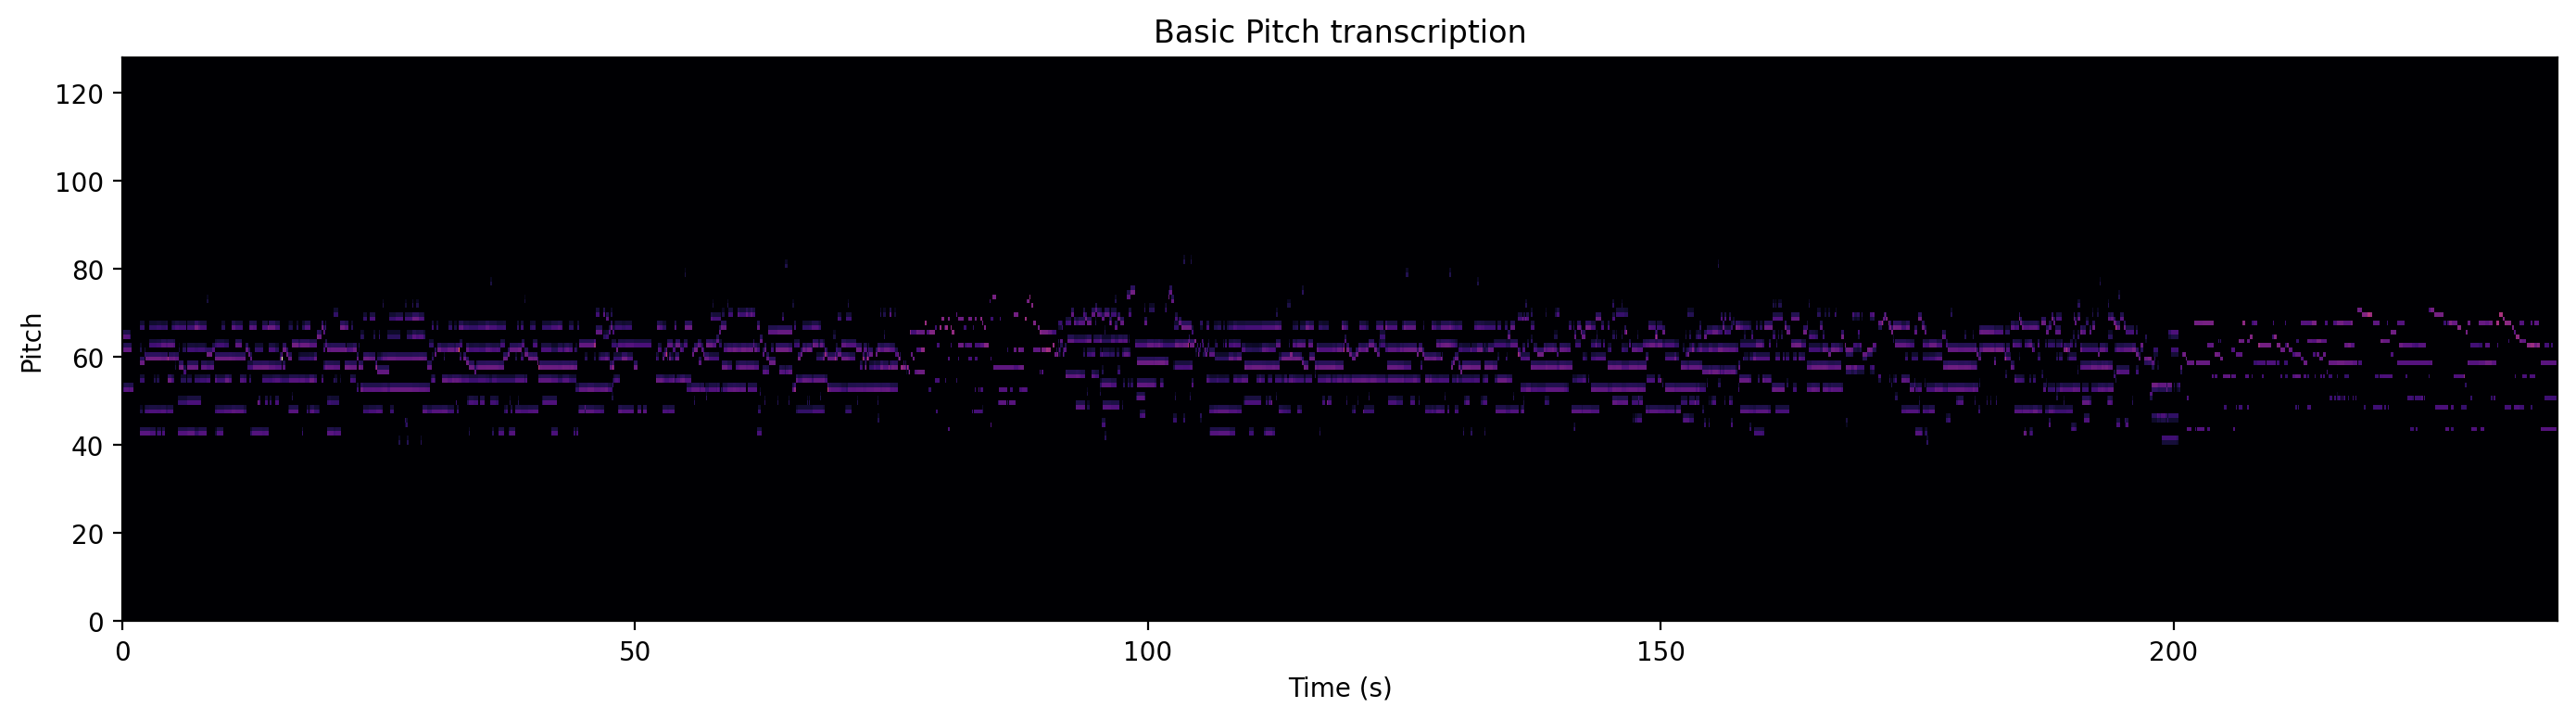


Cell 7 tamamlandi. TRANSCRIBED_MIDI=/content/thesis_joint_e2e/bp_out/transcribed.mid
Cell 8 calistirmaya hazir.


In [ ]:
import glob
import urllib.request  # PATCH BUG-3: MAESTRO download
import zipfile         # PATCH BUG-3: zip extraction
# Cell 7 - Upload audio / fallback synthetic + download MAESTRO + Basic Pitch transcription
AUDIO_PATH = ROOT + "/input.wav"

try:
    from google.colab import files as colab_files
    print("Upload a WAV/MP3 file or cancel for a synthetic test tone.")
    uploaded = colab_files.upload()
    if uploaded:
        fname=list(uploaded.keys())[0]
        AUDIO_PATH=f"/content/{fname}"
        print("Using uploaded file:", AUDIO_PATH)
    else:
        raise ValueError("no upload")
except Exception:
    sr=CFG["sr"]
    t=np.linspace(0, 0.5, sr//2, endpoint=False)
    sig=(np.sin(2*np.pi*261.63*t) + 0.5*np.sin(2*np.pi*329.63*t) + 0.3*np.sin(2*np.pi*392.00*t))
    sig=np.tile(sig, 6)
    sig=(sig / (np.abs(sig).max()+1e-8) * 0.9).astype(np.float32)
    sf.write(AUDIO_PATH, sig, sr)
    print("Synthetic audio created:", AUDIO_PATH)

# -- MAESTRO: zaten varsa tekrar indirme (idempotent) --
maestro_zip = "/content/maestro.zip"
MIDI_DIR    = ROOT + "/maestro-v3.0.0"

if os.path.isdir(MIDI_DIR) and len(glob.glob(MIDI_DIR + "/**/*.mid", recursive=True)) > 100:
    print(f"MAESTRO zaten mevcut: {MIDI_DIR}  (indirme atlandi)")
else:
    print("\nMAESTRO MIDI indiriliyor (~1.2 GB, ~5 dk)...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip",
        maestro_zip
    )
    print("Indirme tamam. Aciliyor...")
    with zipfile.ZipFile(maestro_zip) as zf:
        zf.extractall(ROOT)
    print("Acma tamam.")

midi_files = glob.glob(MIDI_DIR + "/**/*.mid", recursive=True) + \
             glob.glob(MIDI_DIR + "/**/*.midi", recursive=True)
print("MIDI_DIR:", MIDI_DIR)
print("MIDI files:", len(midi_files))

print("\nRunning Basic Pitch transcription...")
# -- TF GPU devre disi -- GPU ortaminda "No DNN in stream executor" hatasini onler
import os as _bp_os
try:
    import tensorflow as _bp_tf
    _bp_tf.config.set_visible_devices([], "GPU")
    print("[BasicPitch] TensorFlow GPU devre disi -- CPU inference aktif.")
except Exception as _bp_e:
    print(f"[BasicPitch] TF GPU disable uyarisi (zararsiz): {_bp_e}")
from basic_pitch.inference import predict
bp_dir = ROOT + "/bp_out"
os.makedirs(bp_dir, exist_ok=True)
_, midi_data, note_events = predict(
    AUDIO_PATH,
    onset_threshold=0.5,
    frame_threshold=0.3,
    minimum_note_length=58,
    minimum_frequency=32.7,
    maximum_frequency=2093.0,
    multiple_pitch_bends=True,
    melodia_trick=True,
)
TRANSCRIBED_MIDI = bp_dir + "/transcribed.mid"
midi_data.write(TRANSCRIBED_MIDI)

n_notes=sum(len(inst.notes) for inst in midi_data.instruments)
duration=midi_data.get_end_time()
print("TRANSCRIBED_MIDI:", TRANSCRIBED_MIDI)
print(f"notes={n_notes} duration={duration:.2f}s")

plot_piano_roll(TRANSCRIBED_MIDI, title="Basic Pitch transcription")

# -- Guard: Cell 8 icin zorunlu degiskenleri dogrula --
assert os.path.exists(TRANSCRIBED_MIDI), (
    f"TRANSCRIBED_MIDI olusturulamadi: {TRANSCRIBED_MIDI}\n"
    "Basic Pitch yukarida hata vermis olmali. Yukaridaki hata mesajini kontrol et."
)
assert len(midi_files) > 0, (
    f"MAESTRO MIDI dosyasi bulunamadi: {MIDI_DIR}\n"
    "MAESTRO indirme basarisiz olmus olabilir. Hucreyi tekrar calistir."
)
print(f"\nCell 7 tamamlandi. TRANSCRIBED_MIDI={TRANSCRIBED_MIDI}")
print(f"Cell 8 calistirmaya hazir.")


In [ ]:
# Cell 8 - Extract chord, key, mood from user input
def extract_chords(midi_path, window_sec=2.0):
    midi=pretty_midi.PrettyMIDI(midi_path)
    notes=[n for inst in midi.instruments if not inst.is_drum for n in inst.notes]
    chords=[]
    t=0.0
    while t < midi.get_end_time():
        t_end=min(t+window_sec, midi.get_end_time())
        active=list({n.pitch for n in notes if n.start < t_end and n.end > t})
        if active:
            try:
                name=m21.chord.Chord([m21.note.Note(p) for p in active]).commonName
            except Exception:
                name="unknown"
            chords.append({"start": t, "end": t_end, "chord": name})
        t += window_sec
    return chords

chords=extract_chords(TRANSCRIBED_MIDI)
print("Chord progression:")
for c in chords[:6]:
    print(f"  [{c['start']:.1f}-{c['end']:.1f}s] {c['chord']}")

try:
    KEY=str(m21.converter.parse(TRANSCRIBED_MIDI).analyze("key"))
except Exception as e:
    KEY="C major"
print("KEY:", KEY)

CHORD_IDX = chord_name_to_idx(chords[0]["chord"]) if chords else 24
print("CHORD_IDX:", CHORD_IDX)

user_pm=pretty_midi.PrettyMIDI(TRANSCRIBED_MIDI)
MOOD_IDX=heuristic_mood_label_from_pm(user_pm)
print("MOOD_IDX:", MOOD_IDX, MOOD_LABELS[MOOD_IDX])

seed_tokens = midi_to_tokens(TRANSCRIBED_MIDI, max_notes=64)
seed_tokens = seed_tokens[:CFG["seq_len"]] + [PAD_TOKEN] * (CFG["seq_len"] - len(seed_tokens[:CFG["seq_len"]]))
seed_tensor = torch.tensor(seed_tokens, dtype=torch.long)


Chord progression:
  [0.0-2.0s] Kumoi pentachord
  [2.0-4.0s] augmented pentacluster
  [4.0-6.0s] minor hexachord
  [6.0-8.0s] major-second minor tetrachord
  [8.0-10.0s] forte class 6-40B
  [10.0-12.0s] minor triad
KEY: b minor
CHORD_IDX: 24
MOOD_IDX: 2 neutral


MIDIDataset: 1276 sequences from /content/thesis_joint_e2e/maestro-v3.0.0
CVAE params: 241469


CVAE epoch 1/20:   0%|          | 0/39 [00:00<?, ?it/s]

epoch=01 loss=3.7025 recon=3.7013 kl=0.1398


CVAE epoch 2/20:   0%|          | 0/39 [00:00<?, ?it/s]

epoch=02 loss=2.9339 recon=2.9303 kl=0.1282


...

epoch=18 loss=2.6015 recon=2.5660 kl=0.1041


CVAE epoch 19/20:   0%|          | 0/39 [00:00<?, ?it/s]

epoch=19 loss=2.5880 recon=2.5500 kl=0.1054


CVAE epoch 20/20:   0%|          | 0/39 [00:00<?, ?it/s]

epoch=20 loss=2.5879 recon=2.5464 kl=0.1092


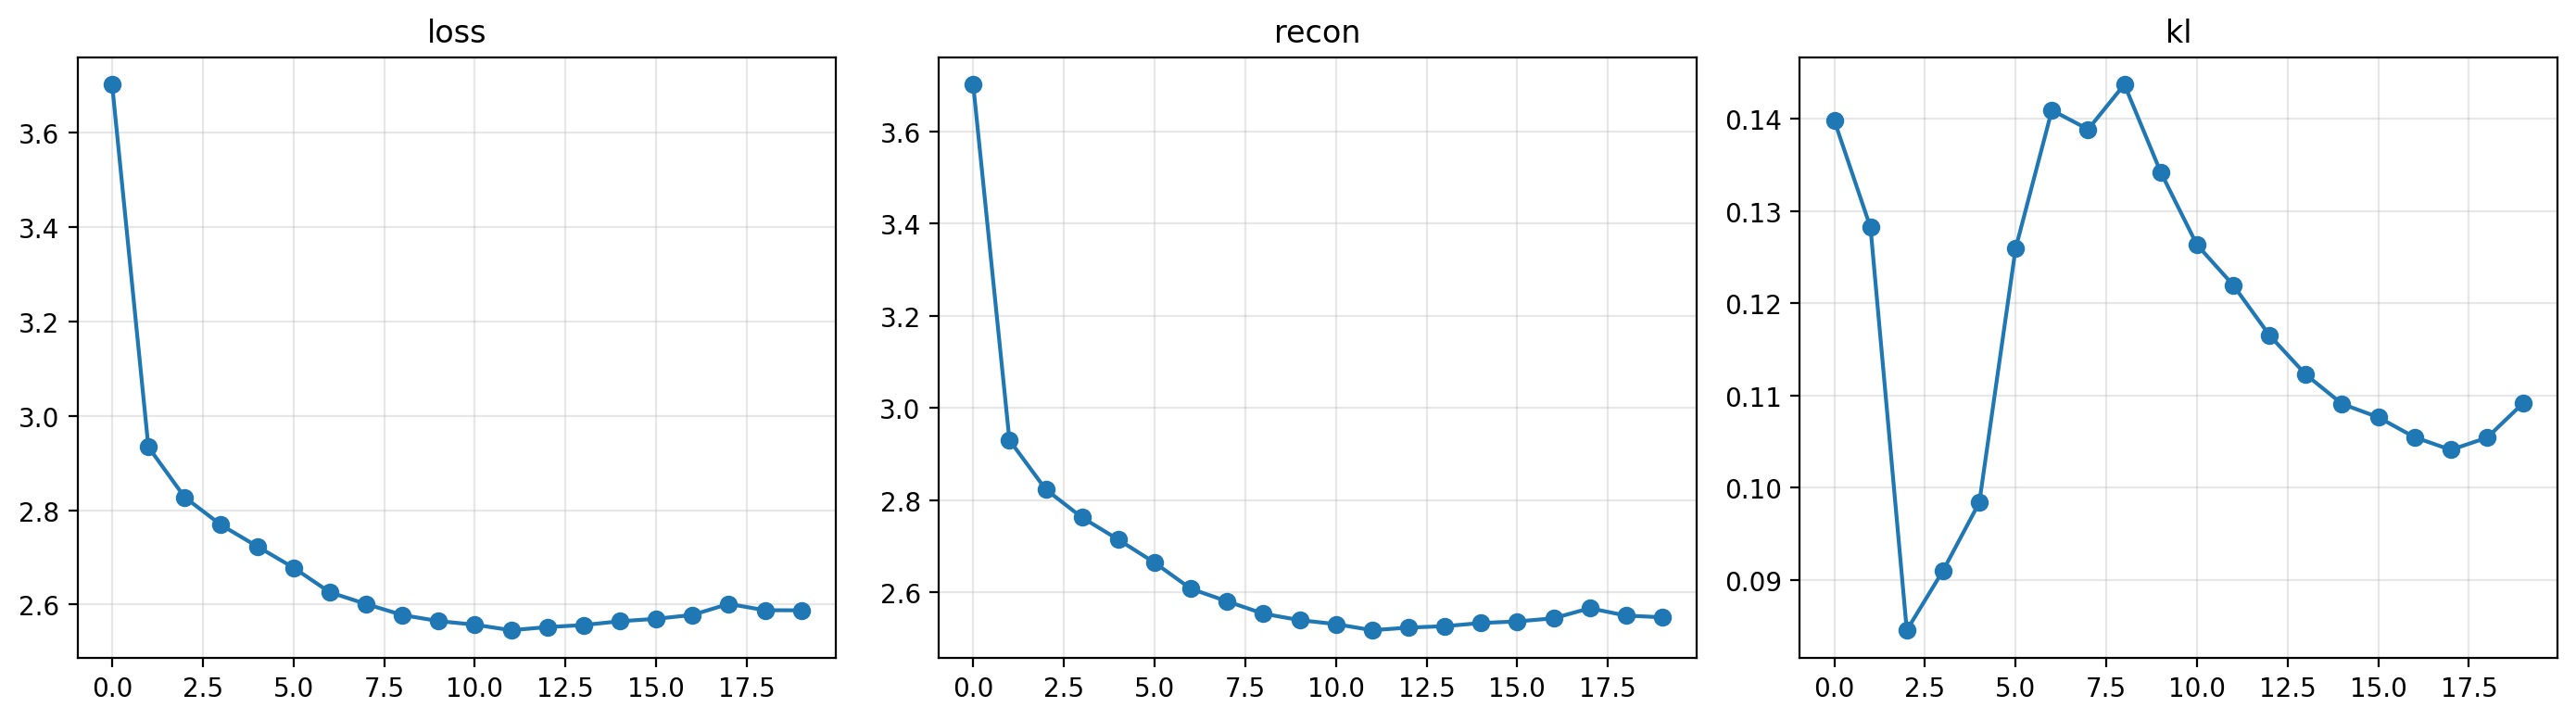

[snapshot] Saved MAESTRO-pretrained baseline before any user FT/RL: /content/thesis_joint_e2e/outputs/cvae_pretrained_baseline_weights.pth


In [ ]:
# Cell 9 - CVAE pretraining (supervised MIDI stage)
midi_dataset = MIDIDataset(MIDI_DIR, seq_len=CFG["seq_len"], max_files=1276)
midi_loader  = DataLoader(midi_dataset, batch_size=CFG["batch"], shuffle=True, drop_last=True, num_workers=0)

cvae_model = MelodyCVAE(CFG).to(DEVICE)
cvae_opt   = ManualAdam(cvae_model.parameters(), lr=CFG["cvae_lr"], wd=1e-4)

cvae_history={"loss": [], "recon": [], "kl": []}
global_step=0

print("CVAE params:", sum(p.numel() for p in cvae_model.parameters()))

# Resume from latest epoch checkpoint if available
_cvae_ckpts = sorted(
    [f for f in os.listdir(OUT_DIR) if f.startswith("cvae_ckpt_epoch_") and f.endswith(".pth")],
    key=lambda f: int(f.replace("cvae_ckpt_epoch_", "").replace(".pth", "")),
)
_cvae_start_epoch = 1
if _cvae_ckpts:
    _ckpt = torch.load(os.path.join(OUT_DIR, _cvae_ckpts[-1]), map_location=DEVICE)
    cvae_model.load_state_dict(_ckpt["cvae"])
    cvae_opt.load_state_dict(_ckpt["opt"])
    cvae_history = _ckpt["history"]
    global_step = _ckpt["global_step"]
    _cvae_start_epoch = _ckpt["epoch"] + 1
    print(f"[resume] CVAE training from epoch {_cvae_start_epoch} (loaded {_cvae_ckpts[-1]})")

for epoch in range(_cvae_start_epoch, CFG["cvae_epochs"]+1):
    cvae_model.train()
    loss_sum=recon_sum=kl_sum=0.0
    for batch in tqdm(midi_loader, desc=f"CVAE epoch {epoch}/{CFG['cvae_epochs']}", leave=False):
        tokens=batch.to(DEVICE)
        B=tokens.size(0)
        mood_idx=[tokens_to_mood_idx(tokens[i].tolist()) for i in range(B)]
        chord_idx=[tokens_to_chord_idx(tokens[i].tolist()) for i in range(B)]
        bar_idx=[tokens_to_bar_idx(tokens[i].tolist(), n_bins=CFG["n_bar_bins"]) for i in range(B)]
        mood_oh=build_mood_onehot(mood_idx, n_moods=CFG["n_moods"], device=DEVICE)
        chord_t_=torch.tensor(chord_idx, dtype=torch.long, device=DEVICE)  # PATCH BUG-7
        bar_t_=torch.tensor(bar_idx, dtype=torch.long, device=DEVICE)  # PATCH BUG-7
        tf_ratio=max(0.1, 1.0 - global_step / max(1, CFG["cvae_epochs"]*len(midi_loader)))
        cvae_opt.zero_grad()
        loss, recon, kl = cvae_model.loss(tokens, mood_oh, chord_idx=chord_t_, bar_idx=bar_t_, step=global_step, teacher_force=tf_ratio)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cvae_model.parameters(), 1.0)
        cvae_opt.step()
        loss_sum += float(loss.item())
        recon_sum += recon
        kl_sum += kl
        global_step += 1
    n=len(midi_loader)
    cvae_history["loss"].append(loss_sum/n)
    cvae_history["recon"].append(recon_sum/n)
    cvae_history["kl"].append(kl_sum/n)
    print(f"epoch={epoch:02d} loss={loss_sum/n:.4f} recon={recon_sum/n:.4f} kl={kl_sum/n:.4f}")
    if epoch % 5 == 0:
        _ckpt_path = os.path.join(OUT_DIR, f"cvae_ckpt_epoch_{epoch}.pth")
        torch.save(
            {"cvae": cvae_model.state_dict(), "opt": cvae_opt.state_dict(),
             "epoch": epoch, "global_step": global_step, "history": cvae_history},
            _ckpt_path,
        )
        print(f"[checkpoint] Saved CVAE epoch {epoch}: {_ckpt_path}")

fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, key in zip(axes, ["loss", "recon", "kl"]):
    ax.plot(cvae_history[key], marker="o")
    ax.set_title(key)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/cvae_training_curves.png", dpi=140, bbox_inches="tight")
plt.show()

# PATCH: preserve a true MAESTRO-pretrained baseline before any user fine-tuning or RL.
def snapshot_state_dict(model_or_state):
    state = model_or_state.state_dict() if hasattr(model_or_state, 'state_dict') else model_or_state
    return {k: v.detach().cpu().clone() for k, v in state.items()}

PRETRAINED_CVAE_STATE = snapshot_state_dict(cvae_model)
PRETRAINED_WEIGHT_OUT = OUT_DIR + '/cvae_pretrained_baseline_weights.pth'
USER_FT_CVAE_STATE = None
USER_FT_DONE = False
RL_GUIDED_CVAE_STATE = None

torch.save({'cfg': CFG, 'tag': 'maestro_pretrained_baseline', 'cvae': PRETRAINED_CVAE_STATE}, PRETRAINED_WEIGHT_OUT)
print(f'[snapshot] Saved MAESTRO-pretrained baseline before any user FT/RL: {PRETRAINED_WEIGHT_OUT}')


## ADIM 8: Kullanici Ses Kayitlariyla CVAE Domain Adaptation

> Kendi vokal / gitar kayitlarinizi kullanarak CVAE'yi kendi sarzinize adapte eder.

> **Gereksinim:** ADIM 1 (Drive Setup) calistirilmis olmali --> `/content/raw_recordings/` dolu olmali.

> **Calistirma sirasi:**
> 1. **Cell A1** -- Drive path dogrula, `USER_AUDIO_DIR` ayarla
> 2. **Hazirlik hucresi** -- M4A/MP3/WAV -> normalize WAV (`/content/user_ft_input_audio/`)
> 3. **[Opsiyonel] Debug hucresi** -- Kac ses dosyasi bulundu kontrol et
> 4. **Cell A2** -- 15 saniyeye bol, sessizlik QC, manifest olustur
> 5. **Cell A3** -- Basic Pitch transkripsiyon + CVAE fine-tune


In [ ]:
# Cell A1 – Google Drive mount + path setup
# PATCH: Drive ingestion now supports zip/tar/tar.gz/tgz archives with graceful fallback.
import os, tarfile
from pathlib import Path  # PATCH BUG-2: Path used in _extract_supported_archive

DRIVE_MOUNTED = False
try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    DRIVE_MOUNTED = True
    print('Drive mounted.')
except Exception as e:
    print(f'Drive not available ({e}). Set paths manually below.')

USER_AUDIO_DIR  = CFG['user_ft_audio_dir']
PSEUDO_SONG_DIR = CFG['pseudo_pair_audio_dir']
DRIVE_ARCHIVE = ''

def _extract_supported_archive(archive_path, extract_to):
    if zipfile.is_zipfile(archive_path):
        with zipfile.ZipFile(archive_path) as zf:
            zf.extractall(extract_to)
        return 'zip'
    if tarfile.is_tarfile(archive_path):
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(extract_to)
        suffixes = ''.join(Path(archive_path).suffixes[-2:]) or Path(archive_path).suffix
        return suffixes.lstrip('.') or 'tar'
    raise ValueError('unsupported archive format; use .zip, .tar, .tar.gz, or .tgz')

if DRIVE_ARCHIVE and os.path.exists(DRIVE_ARCHIVE):
    extract_to = '/content/user_audio_extracted'
    os.makedirs(extract_to, exist_ok=True)
    try:
        archive_kind = _extract_supported_archive(DRIVE_ARCHIVE, extract_to)
        USER_AUDIO_DIR = extract_to
        print(f'[archive] Extracted {archive_kind}: {DRIVE_ARCHIVE} -> {USER_AUDIO_DIR}')
    except Exception as e:
        print(f'[archive] Extraction failed for {DRIVE_ARCHIVE}: {e}')
        print('[archive] Continuing without extraction. Supported formats: .zip, .tar, .tar.gz, .tgz')
else:
    print(f'USER_AUDIO_DIR: {USER_AUDIO_DIR}')
    print(f'PSEUDO_SONG_DIR: {PSEUDO_SONG_DIR}')


Drive mounted.
USER_AUDIO_DIR: /content/raw_recordings
PSEUDO_SONG_DIR: /content/user_ft_input_audio


In [ ]:
# User fine-tune için kayıtları hazırla (A1'den sonra, A2'den önce)
import os
import shutil
import subprocess

if 'CFG' not in globals():
    raise RuntimeError(
        "CFG is not defined. Run 'Cell 2 - Setup, seed, config' first."
    )

# Fine-tune'ı aç
CFG['use_user_finetune'] = True

# Ham kayıtların bulunduğu klasör
RAW_RECORDINGS_DIR = '/content/raw_recordings'

# Hazırlanmış audio klasörü
PREPARED_AUDIO_DIR = '/content/user_ft_input_audio'
os.makedirs(PREPARED_AUDIO_DIR, exist_ok=True)

# Uzantılar
audio_exts = {'.wav', '.mp3', '.flac', '.ogg', '.m4a', '.aiff', '.aif'}
video_exts = {'.mp4', '.mov', '.mkv', '.avi', '.webm'}

if not os.path.isdir(RAW_RECORDINGS_DIR):
    raise RuntimeError(f'RAW_RECORDINGS_DIR not found: {RAW_RECORDINGS_DIR}')

ffmpeg_ok = shutil.which('ffmpeg') is not None
print('ffmpeg found =', ffmpeg_ok)

copied_audio = 0
converted_video = 0
failed = []

sr_target = int(CFG.get('sr', 16000))

for root, dirs, files in os.walk(RAW_RECORDINGS_DIR):
    for f in sorted(files):
        src = os.path.join(root, f)
        ext = os.path.splitext(f)[1].lower()
        base = os.path.splitext(f)[0]

        if ext in audio_exts:
            dst = os.path.join(PREPARED_AUDIO_DIR, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
            copied_audio += 1

        elif ext in video_exts:
            if not ffmpeg_ok:
                failed.append((src, 'ffmpeg not found'))
                continue

            safe_base = base.replace('/', '_').replace('\\', '_')
            dst = os.path.join(PREPARED_AUDIO_DIR, safe_base + '.wav')

            if not os.path.exists(dst):
                cmd = [
                    'ffmpeg', '-y',
                    '-i', src,
                    '-vn',
                    '-ac', '1',
                    '-ar', str(sr_target),
                    dst
                ]
                r = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
                if r.returncode != 0:
                    failed.append((src, r.stderr[-300:]))
                    continue

            converted_video += 1

# A2'nin kullanacağı yolu ayarla
CFG['user_ft_audio_dir'] = PREPARED_AUDIO_DIR
USER_AUDIO_DIR = CFG['user_ft_audio_dir']

prepared_files = []
for root, dirs, files in os.walk(USER_AUDIO_DIR):
    for f in sorted(files):
        prepared_files.append(os.path.join(root, f))

print('\n=== USER FT INPUT SUMMARY ===')
print('use_user_finetune =', CFG['use_user_finetune'])
print('user_ft_audio_dir =', USER_AUDIO_DIR)
print('exists =', os.path.isdir(USER_AUDIO_DIR))
print('copied_audio =', copied_audio)
print('converted_video =', converted_video)
print('total_prepared_files =', len(prepared_files))

print('\nFirst prepared files:')
for p in prepared_files[:20]:
    print(' -', p)

if failed:
    print('\nFailed files:')
    for src, msg in failed[:20]:
        print(' -', src, '|', msg)

if len(prepared_files) == 0:
    raise RuntimeError(
        'No usable audio files were prepared. Check RAW_RECORDINGS_DIR, file extensions, and ffmpeg.'
    )

ffmpeg found = True

=== USER FT INPUT SUMMARY ===
use_user_finetune = True
user_ft_audio_dir = /content/user_ft_input_audio
exists = True
copied_audio = 79
converted_video = 0
total_prepared_files = 79

First prepared files:
 - /content/user_ft_input_audio/11111.wav
 - /content/user_ft_input_audio/11111111.wav
 - /content/user_ft_input_audio/132.m4a
 - /content/user_ft_input_audio/14 Ocak MY IMMORTAL - Ses_Audio.wav
 - /content/user_ft_input_audio/2-1-cant cry along.wav
 - /content/user_ft_input_audio/5-brg.wav
 - /content/user_ft_input_audio/6-sleepin on your cobble bed.wav
 - /content/user_ft_input_audio/Abisiktirgit.m4a
 - /content/user_ft_input_audio/Baraj Cd. 14.m4a
 - /content/user_ft_input_audio/Baraj Cd. 19.m4a
 - /content/user_ft_input_audio/Baraj Cd. 25.m4a
 - /content/user_ft_input_audio/Baraj Cd. 48⭐️.m4a
 - /content/user_ft_input_audio/Baraj Cd. 6 (1).m4a
 - /content/user_ft_input_audio/Baraj Cd. 6.m4a
 - /content/user_ft_input_audio/Baraj Cd. 76.m4a
 - /content/user_ft_i

In [ ]:
# -- [Istege Bagli -- Hata Ayiklama] --
# Cell A2 yi calistirmadan once audio klasorunu dogrulamak istiyorsaniz
# bu hucreyi calistirin. Ana pipeline icin zorunlu degildir; atlanabilir.
# -------------------------------------------------------------------------
# DEBUG — A2'ye girmeden önce input kontrolü
import os

print('=== DEBUG BEFORE A2 ===')
print('CFG["use_user_finetune"] =', CFG.get('use_user_finetune'))
print('CFG["user_ft_audio_dir"] =', CFG.get('user_ft_audio_dir'))
print('USER_AUDIO_DIR =', globals().get('USER_AUDIO_DIR', None))

audio_dir = globals().get('USER_AUDIO_DIR', CFG.get('user_ft_audio_dir'))
print('audio_dir exists =', os.path.isdir(audio_dir) if audio_dir else False)

AUDIO_EXTS_DEBUG = {'.wav', '.mp3', '.flac', '.ogg', '.m4a', '.aiff', '.aif'}

all_files = []
audio_files = []

if audio_dir and os.path.isdir(audio_dir):
    for root, dirs, files in os.walk(audio_dir):
        for f in sorted(files):
            full = os.path.join(root, f)
            ext = os.path.splitext(f)[1].lower()
            all_files.append(full)
            if ext in AUDIO_EXTS_DEBUG:
                audio_files.append(full)

print('total files in folder =', len(all_files))
print('supported audio files =', len(audio_files))

print('\nFirst 20 supported audio files:')
for p in audio_files[:20]:
    print(' -', p)

if len(audio_files) == 0:
    print('\n[PROBLEM] A2 hiçbir desteklenen audio dosyası bulamayacak.')
else:
    print('\n[OK] A2 bu klasörü işlemeye başlayabilir.')

=== DEBUG BEFORE A2 ===
CFG["use_user_finetune"] = True
CFG["user_ft_audio_dir"] = /content/user_ft_input_audio
USER_AUDIO_DIR = /content/user_ft_input_audio
audio_dir exists = True
total files in folder = 79
supported audio files = 79

First 20 supported audio files:
 - /content/user_ft_input_audio/11111.wav
 - /content/user_ft_input_audio/11111111.wav
 - /content/user_ft_input_audio/132.m4a
 - /content/user_ft_input_audio/14 Ocak MY IMMORTAL - Ses_Audio.wav
 - /content/user_ft_input_audio/2-1-cant cry along.wav
 - /content/user_ft_input_audio/5-brg.wav
 - /content/user_ft_input_audio/6-sleepin on your cobble bed.wav
 - /content/user_ft_input_audio/Abisiktirgit.m4a
 - /content/user_ft_input_audio/Baraj Cd. 14.m4a
 - /content/user_ft_input_audio/Baraj Cd. 19.m4a
 - /content/user_ft_input_audio/Baraj Cd. 25.m4a
 - /content/user_ft_input_audio/Baraj Cd. 48⭐️.m4a
 - /content/user_ft_input_audio/Baraj Cd. 6 (1).m4a
 - /content/user_ft_input_audio/Baraj Cd. 6.m4a
 - /content/user_ft_input_a

In [ ]:
!pip install soundfile
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
# Cell A2 – Audio segmentation, long-silence removal, silence QC, manifest export
# PATCH: 15-sec clips with configurable overlap; splits around internal silences >7s first
import os, csv, math
import numpy as np

try:
    import librosa
    import soundfile as sf
except ImportError as exc:
    raise RuntimeError(
        "Missing audio dependencies (librosa/soundfile). Run Cell 1 first or repair the setup environment."
    ) from exc

# GUARD BUG-5: ensure USER_AUDIO_DIR is defined even if Cell A1 / prep cell was skipped.
if 'USER_AUDIO_DIR' not in globals():
    if 'CFG' in globals():
        USER_AUDIO_DIR = CFG.get('user_ft_audio_dir', '/content/raw_recordings')
        print(f'[guard] USER_AUDIO_DIR set from CFG: {USER_AUDIO_DIR}')
    else:
        raise RuntimeError(
            'USER_AUDIO_DIR is not defined and CFG is unavailable.\n'
            'Run Cell 2 then Cell A1 (or the prep cell) before Cell A2.'
        )

SEG_DIR = ROOT + '/user_segments'
os.makedirs(SEG_DIR, exist_ok=True)
MANIFEST_PATH = OUT_DIR + '/user_clips_manifest.csv'

SEG_SEC      = CFG['user_ft_segment_sec']
OVERLAP_SEC  = CFG['user_ft_overlap_sec']
SR           = CFG['sr']
LONG_SIL_SEC = CFG['user_ft_long_silence_sec']
SIL_DB       = CFG['user_ft_silence_db_thresh']
MAX_SIL_R    = CFG['user_ft_max_silence_ratio']
MIN_V_SEC    = CFG['user_ft_min_voiced_sec']
TRIM_LONG    = CFG['user_ft_trim_long_silence']
AUDIO_EXTS   = {'.wav', '.mp3', '.flac', '.ogg', '.m4a', '.aiff', '.aif'}

def _silence_ratio(y, threshold_db=-50.0, frame_len=512):
    frames = librosa.util.frame(y, frame_length=frame_len, hop_length=frame_len // 2)
    frame_rms = np.sqrt(np.mean(frames ** 2, axis=0) + 1e-12)
    frame_db  = 20.0 * np.log10(frame_rms + 1e-12)
    return float(np.mean(frame_db < threshold_db))

def _find_long_silence_gaps(y, sr, min_sec=7.0, thresh_db=-50.0, frame_len=512, hop=256):
    '''Return (start_sample, end_sample) for silence runs > min_sec. Conservative.'''
    frame_rms = np.array([
        np.sqrt(np.mean(y[i:i+frame_len] ** 2) + 1e-12)
        for i in range(0, len(y) - frame_len + 1, hop)])
    frame_db  = 20.0 * np.log10(frame_rms + 1e-12)
    is_silent = frame_db < thresh_db
    min_frames = int(min_sec * sr / hop)
    gaps, run_start = [], None
    for fi, s in enumerate(is_silent):
        if s and run_start is None:
            run_start = fi
        elif not s and run_start is not None:
            if (fi - run_start) >= min_frames:
                gaps.append((run_start * hop, fi * hop))
            run_start = None
    if run_start is not None and (len(is_silent) - run_start) >= min_frames:
        gaps.append((run_start * hop, len(y)))
    return gaps

def _split_around_gaps(y, sr, gaps):
    if not gaps:
        return [(y, 0, len(y))]
    segs, prev_end = [], 0
    for gs, ge in gaps:
        chunk = y[prev_end:gs]
        if len(chunk) / sr > 1.0:
            segs.append((chunk, prev_end, gs))
        prev_end = ge
    tail = y[prev_end:]
    if len(tail) / sr > 1.0:
        segs.append((tail, prev_end, len(y)))
    return segs if segs else [(y, 0, len(y))]

def _scan_audio(folder):
    found = []
    for root_, _, files in os.walk(folder):
        for fn in sorted(files):
            if os.path.splitext(fn)[1].lower() in AUDIO_EXTS:
                found.append(os.path.join(root_, fn))
    return found

manifest_rows = []

if not CFG['use_user_finetune']:
    print('use_user_finetune=False – skipping. Set True to process your recordings.')
elif not os.path.isdir(USER_AUDIO_DIR):
    print(f'USER_AUDIO_DIR not found: {USER_AUDIO_DIR} – skipping.')
else:
    audio_files = _scan_audio(USER_AUDIO_DIR)
    print(f'Found {len(audio_files)} audio files in {USER_AUDIO_DIR}')
    step = SEG_SEC - OVERLAP_SEC
    clip_count = 0
    for af in audio_files:
        basename = os.path.splitext(os.path.basename(af))[0]
        try:
            y_full, _ = librosa.load(af, sr=SR, mono=True)
        except Exception as e:
            print(f'  SKIP (load error): {af}: {e}'); continue
        gaps = _find_long_silence_gaps(y_full, SR, LONG_SIL_SEC, SIL_DB) if TRIM_LONG else []
        audio_chunks = _split_around_gaps(y_full, SR, gaps)
        for chunk_audio, chunk_s, chunk_e in audio_chunks:
            orig_start = chunk_s / SR
            orig_end   = chunk_e / SR
            chunk_dur  = len(chunk_audio) / SR
            if chunk_dur < 2.0:
                continue
            n_clips = max(1, int(math.ceil((chunk_dur - SEG_SEC) / step + 1)))
            for ci in range(n_clips):
                t0 = ci * step; t1 = t0 + SEG_SEC
                s0 = int(t0 * SR); s1 = min(int(t1 * SR), len(chunk_audio))
                clip = chunk_audio[s0:s1]
                dur  = len(clip) / SR
                if dur < 2.0:
                    break
                sil_r      = _silence_ratio(clip, SIL_DB)
                voiced_sec = dur * (1.0 - sil_r)
                keep       = True; drop_reason = ''
                if sil_r > MAX_SIL_R:
                    keep = False; drop_reason = f'silence_ratio={sil_r:.2f}>{MAX_SIL_R}'
                elif voiced_sec < MIN_V_SEC:
                    keep = False; drop_reason = f'voiced_sec={voiced_sec:.1f}<{MIN_V_SEC}'
                clip_fname = f'{basename}__t{orig_start+t0:.1f}-{orig_start+t1:.1f}s__c{clip_count:04d}.wav'
                clip_path  = os.path.join(SEG_DIR, clip_fname)
                if keep:
                    sf.write(clip_path, clip, SR)
                    clip_count += 1
                manifest_rows.append({
                    'source_file': af,
                    'clip_file':   clip_path if keep else '',
                    'clip_start_sec':   round(orig_start + t0, 3),
                    'clip_end_sec':     round(orig_start + t1, 3),
                    'clip_duration_sec': round(dur, 3),
                    'keep_flag':   int(keep),
                    'drop_reason': drop_reason,
                    'estimated_silence_ratio': round(sil_r, 4),
                    'original_start_sec': round(orig_start, 3),
                    'original_end_sec':   round(orig_end, 3),
                    'trimmed_start_sec':  round(orig_start + t0, 3),
                    'trimmed_end_sec':    round(orig_start + t1, 3),
                })
    kept    = sum(r['keep_flag'] for r in manifest_rows)
    dropped = len(manifest_rows) - kept
    print(f'Clips: {len(manifest_rows)}  kept={kept}  dropped={dropped}  saved={clip_count}')
    if manifest_rows:
        with open(MANIFEST_PATH, 'w', newline='') as fh:
            w = csv.DictWriter(fh, fieldnames=list(manifest_rows[0].keys()))
            w.writeheader(); w.writerows(manifest_rows)
        print(f'Manifest: {MANIFEST_PATH}')


Found 79 audio files in /content/user_ft_input_audio


/tmp/ipython-input-25-2814718906.py:101: UserWarning: PySoundFile failed. Trying audioread instead.
  y_full, _ = librosa.load(af, sr=SR, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipython-input-25-2814718906.py:101: UserWarning: PySoundFile failed. Trying audioread instead.
  y_full, _ = librosa.load(af, sr=SR, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipython-input-25-2814718906.py:101: UserWarning: PySoundFile failed. Trying audioread instead.
  y_full, _ = librosa.load(af, sr=SR, mono=True)
/usr/local/lib/

Clips: 1218  kept=1204  dropped=14  saved=1204
Manifest: /content/thesis_joint_e2e/outputs/user_clips_manifest.csv


In [ ]:
# Cell A3 – Transcribe kept clips → tokens → CVAE fine-tune (domain adaptation only)
# PATCH: fingerprinted cache + restored pretrained snapshot + separate saved user-FT state.
import os, json, hashlib
from pathlib import Path

FT_CACHE_DIR   = ROOT + '/user_ft_cache'
FT_CACHE_META  = FT_CACHE_DIR + '/cache_meta.json'
FT_WEIGHT_OUT  = OUT_DIR + '/cvae_user_ft_weights.pth'
USER_FT_DONE   = False
USER_FT_CVAE_STATE = None
os.makedirs(FT_CACHE_DIR, exist_ok=True)

BP_CFG = dict(
    onset_threshold=0.5,
    frame_threshold=0.3,
    minimum_note_length=58,
    minimum_frequency=32.7,
    maximum_frequency=2093.0,
    multiple_pitch_bends=True,
    melodia_trick=True,
)

def _ft_cache_payload(cfg, manifest_path, bp_cfg):
    manifest_bytes = Path(manifest_path).read_bytes() if os.path.exists(manifest_path) else b''
    return {
        'manifest_sha256': hashlib.sha256(manifest_bytes).hexdigest(),
        'segmentation_cfg': {
            'sr': cfg['sr'],
            'user_ft_segment_sec': cfg['user_ft_segment_sec'],
            'user_ft_overlap_sec': cfg['user_ft_overlap_sec'],
            'user_ft_min_voiced_sec': cfg['user_ft_min_voiced_sec'],
            'user_ft_max_silence_ratio': cfg['user_ft_max_silence_ratio'],
            'user_ft_long_silence_sec': cfg['user_ft_long_silence_sec'],
            'user_ft_silence_db_thresh': cfg['user_ft_silence_db_thresh'],
            'user_ft_trim_long_silence': cfg['user_ft_trim_long_silence'],
        },
        'transcription_cfg': {
            'seq_len': cfg['seq_len'],
            'user_ft_min_notes': cfg['user_ft_min_notes'],
            'user_ft_min_duration': cfg['user_ft_min_duration'],
            'basic_pitch': bp_cfg,
        },
    }

def _ft_cache_fingerprint(payload):
    raw = json.dumps(payload, sort_keys=True).encode('utf-8')
    return hashlib.sha256(raw).hexdigest()[:16]

if not CFG['use_user_finetune'] or not manifest_rows:
    print('Skipping user fine-tuning (use_user_finetune=False or no manifest).')
else:
    # -- TF GPU devre disi (Cell 13 ile ayni guvenlik onlemi) --
    import os as _a3_os
    try:
        import tensorflow as _a3_tf
        _a3_tf.config.set_visible_devices([], "GPU")
        print("[user-ft BP] TensorFlow GPU devre disi -- CPU inference aktif.")
    except Exception as _a3_e:
        print(f"[user-ft BP] TF GPU disable uyarisi (zararsiz): {_a3_e}")
    from basic_pitch.inference import predict as bp_predict
    cvae_model.load_state_dict(PRETRAINED_CVAE_STATE)
    print('[user-ft] Restored preserved MAESTRO-pretrained baseline before fine-tuning.')
    cache_payload = _ft_cache_payload(CFG, MANIFEST_PATH, BP_CFG)
    FT_FINGERPRINT = _ft_cache_fingerprint(cache_payload)
    FT_MIDI_DIR    = os.path.join(FT_CACHE_DIR, f'midi_{FT_FINGERPRINT}')
    FT_TOKEN_FILE  = os.path.join(FT_CACHE_DIR, f'ft_tokens_{FT_FINGERPRINT}.pt')
    os.makedirs(FT_MIDI_DIR, exist_ok=True)
    prev_meta = None
    if os.path.exists(FT_CACHE_META):
        try:
            with open(FT_CACHE_META, 'r', encoding='utf-8') as fh:
                prev_meta = json.load(fh)
        except Exception as e:
            print(f'[user-ft cache] Ignoring unreadable cache metadata: {e}')
    prev_fp = prev_meta.get('fingerprint') if isinstance(prev_meta, dict) else None
    kept_clips = [r['clip_file'] for r in manifest_rows if r['keep_flag'] and r['clip_file']]
    print(f'[user-ft] Transcribing {len(kept_clips)} kept clips with Basic Pitch...')
    print(f'[user-ft cache] fingerprint={FT_FINGERPRINT}')
    ft_token_seqs = []
    if os.path.exists(FT_TOKEN_FILE):
        ft_token_seqs = torch.load(FT_TOKEN_FILE, map_location='cpu')
        print(f'[user-ft cache] Reused cached token seqs: {len(ft_token_seqs)} from {FT_TOKEN_FILE}')
    else:
        if prev_fp and prev_fp != FT_FINGERPRINT:
            print(f'[user-ft cache] Invalidated cache: {prev_fp} -> {FT_FINGERPRINT}')
        else:
            print('[user-ft cache] No reusable cache found; building a fresh transcription/token cache.')
        for cp in kept_clips:
            bn = os.path.splitext(os.path.basename(cp))[0]
            mid_out = os.path.join(FT_MIDI_DIR, bn + '.mid')
            try:
                if os.path.exists(mid_out):
                    toks = midi_to_tokens(mid_out, (CFG['seq_len'] - 1) // 2)
                else:
                    _, midi_obj, _ = bp_predict(cp, **BP_CFG)
                    midi_obj.write(mid_out)
                    toks = midi_to_tokens(mid_out, (CFG['seq_len'] - 1) // 2)
            except Exception as e:
                print(f'[user-ft] Basic Pitch failed for {cp}: {e}')
                continue
            n_notes = len([t for t in toks if 0 <= t < 128])
            dur_est = sum(DUR_BINS[min(t - DUR_OFFSET, len(DUR_BINS) - 1)] for t in toks if DUR_OFFSET <= t < TEMPO_OFFSET)
            if n_notes < CFG['user_ft_min_notes'] or dur_est < CFG['user_ft_min_duration']:
                continue
            seq = toks[:CFG['seq_len']] + [PAD_TOKEN] * (CFG['seq_len'] - len(toks[:CFG['seq_len']]))
            ft_token_seqs.append(torch.tensor(seq, dtype=torch.long))
        torch.save(ft_token_seqs, FT_TOKEN_FILE)
        print(f'[user-ft cache] Cached {len(ft_token_seqs)} sequences -> {FT_TOKEN_FILE}')
    with open(FT_CACHE_META, 'w', encoding='utf-8') as fh:
        json.dump({'fingerprint': FT_FINGERPRINT, 'payload': cache_payload}, fh, indent=2)
    if len(ft_token_seqs) < 4:
        print(f'[user-ft] Too few sequences ({len(ft_token_seqs)}) – keeping the pretrained baseline for RL init.')
    else:
        from torch.utils.data import TensorDataset, DataLoader as DL2
        ft_batch_size = min(CFG['user_ft_batch'], len(ft_token_seqs))
        ft_ds = TensorDataset(torch.stack(ft_token_seqs))
        ft_loader = DL2(ft_ds, batch_size=ft_batch_size, shuffle=True, drop_last=False, num_workers=0)
        ft_opt = ManualAdam(cvae_model.parameters(), lr=CFG['user_ft_lr'], wd=1e-4)
        print(f'[user-ft] Fine-tuning CVAE {CFG["user_ft_epochs"]} epochs on {len(ft_token_seqs)} user seqs...')
        cvae_model.train()
        for ep in range(1, CFG['user_ft_epochs'] + 1):
            ep_loss = 0.0
            for (batch,) in ft_loader:
                tokens = batch.to(DEVICE)
                B = tokens.size(0)
                mood_idx  = [tokens_to_mood_idx(tokens[i].tolist()) for i in range(B)]
                chord_idx = [tokens_to_chord_idx(tokens[i].tolist()) for i in range(B)]
                bar_idx   = [tokens_to_bar_idx(tokens[i].tolist(), n_bins=CFG['n_bar_bins']) for i in range(B)]
                mood_oh   = build_mood_onehot(mood_idx, n_moods=CFG['n_moods'], device=DEVICE)
                chord_t_  = torch.tensor(chord_idx, dtype=torch.long, device=DEVICE)
                bar_t_    = torch.tensor(bar_idx, dtype=torch.long, device=DEVICE)
                ft_opt.zero_grad()
                loss, _, _ = cvae_model.loss(tokens, mood_oh, chord_idx=chord_t_, bar_idx=bar_t_, step=99999, teacher_force=0.7)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cvae_model.parameters(), 1.0)
                ft_opt.step()
                ep_loss += float(loss.item())
            print(f'  FT epoch {ep}/{CFG["user_ft_epochs"]}  loss={ep_loss/max(1, len(ft_loader)):.4f}')
        USER_FT_CVAE_STATE = snapshot_state_dict(cvae_model)
        torch.save({'cfg': CFG, 'tag': 'user_finetuned_cvae', 'cache_fingerprint': FT_FINGERPRINT, 'cvae': USER_FT_CVAE_STATE}, FT_WEIGHT_OUT)
        print(f'[snapshot] Saved user fine-tuned CVAE: {FT_WEIGHT_OUT}')
        USER_FT_DONE = True


[user-ft BP] TensorFlow GPU devre disi -- CPU inference aktif.
[user-ft] Restored preserved MAESTRO-pretrained baseline before fine-tuning.
[user-ft] Transcribing 1204 kept clips with Basic Pitch...
[user-ft cache] fingerprint=366b9d2d2911201b
[user-ft cache] No reusable cache found; building a fresh transcription/token cache.
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t0.0-15.0s__c0000.wav...
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t13.0-28.0s__c0001.wav...
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t26.0-41.0s__c0002.wav...
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t39.0-54.0s__c0003.wav...
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t52.0-67.0s__c0004.wav...
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t65.0-80.0s__c0005.wav...
Predicting MIDI for /content/thesis_joint_e2e/user_segments/11111__t78.0-93.0s__c0006.wav...
Predicting MIDI for /

In [ ]:
import os, shutil

dst_dir = '/content/drive/MyDrive/thesis_outputs'
os.makedirs(dst_dir, exist_ok=True)

if USER_FT_DONE and USER_FT_CVAE_STATE is not None:
    shutil.copy(
        '/content/thesis_joint_e2e/outputs/cvae_user_ft_weights.pth',
        os.path.join(dst_dir, 'cvae_user_ft_weights.pth')
    )
else:
    print('[skip] User FT weights not created in this run -- skipping Drive copy.')

FileNotFoundError: [Errno 2] No such file or directory: '/content/thesis_joint_e2e/outputs/cvae_user_ft_weights.pth'

## ADIM 9: RL Egitim Verisi -- Pseudo-Pair Uretimi ve Veri Secici

> **Veri oncelik sirasi (Cell A5):**
> `musdb_full (tam 30GB)` > `musdb_excerpts (7sn gercek stem, otomatik iner)` >
> `pseudo_pairs (Open-Unmix ile kendi kayitlarindan)` > `musdb_preview` > `synthetic`

> **Cell A4:** Kendi ses kayitlarinizi (`/content/user_ft_input_audio/`) vokal ve
> accompaniment stemlerine ayirarak pseudo-pair uretir.

> **Not:** MUSDB18-HQ tam dataset Zenodo'dan lisansli erisim gerektirir (~30GB).
> 7 saniyelik excerpt'ler `pip install musdb` + `download=True` ile otomatik iner.


In [ ]:
# Cell A4 – Pseudo-pair generation via Open-Unmix source separation
# PATCH: robust Open-Unmix invocation + explicit skip/fallback logging.
# NOTE: pseudo-pairs are NOT equivalent to real MUSDB pairs. Labelled accordingly in eval.
import os, csv

_openunmix_available = False
_musdb_available = False
try:
    import openunmix as _ou
    _openunmix_available = True
except ImportError:
    print("[Cell A4] openunmix not installed — pseudo-pair generation will be skipped.")
try:
    import musdb as _musdb_mod
    _musdb_available = True
except ImportError:
    pass

PP_CACHE      = CFG['pseudo_pair_cache_dir']
PP_MANIFEST   = OUT_DIR + '/pseudo_pairs_manifest.csv'
os.makedirs(PP_CACHE, exist_ok=True)
PSEUDO_MEL_PAIRS = []
pseudo_pair_records = []

if not CFG['pseudo_pair_enable']:
    print('pseudo_pair_enable=False – skipping.')
elif not os.path.isdir(CFG['pseudo_pair_audio_dir']):
    print(f'pseudo_pair_audio_dir not found: {CFG["pseudo_pair_audio_dir"]} – skipping.')
    print('[pseudo-pair] Ipucu: Cell 18 (hazirlik hucresi) calistirilmadan')
    print('  /content/user_ft_input_audio olusmuyor. Cell 18 i once calistir.')
else:
    try:
        try:
            import soundfile as _sf
            import librosa as _lib
            import openunmix  # noqa: F401
        except ImportError as exc:
            raise RuntimeError(
                "[pseudo-pair] Missing dependency in setup environment (openunmix/librosa/soundfile). Run Cell 1 first."
            ) from exc
        def _to_mono(audio):
            arr = np.asarray(audio, dtype=np.float32)
            if arr.ndim == 2:
                axis = 1 if arr.shape[0] > arr.shape[1] else 0
                arr = arr.mean(axis=axis)
            return arr.astype(np.float32)



        def _umx_separate_file(audio_path):
            from openunmix.predict import separate as umx_separate
            import librosa as _lbr
            import torch

            TARGET_SR = 44100

            audio_np, sr = _lbr.load(audio_path, sr=TARGET_SR, mono=False)

            if audio_np.ndim == 1:
                audio_np = np.stack([audio_np, audio_np], axis=0)

            audio_tensor = torch.tensor(audio_np, dtype=torch.float32).unsqueeze(0)

            estimates = umx_separate(
                audio_tensor,
                rate=TARGET_SR,
                targets=['vocals', 'other'],
                residual=False,
            )
            return estimates, TARGET_SR

        try:
            # Baglanti testi: import kontrolu
            from openunmix.predict import separate as _umx_test
            umx_runner = _umx_separate_file
            umx_runner_label = 'openunmix.predict.separate (numpy+rate)'
            print(f'[pseudo-pair] Open-Unmix hazir: {umx_runner_label}')
        except Exception as e:
            print(f'[pseudo-pair] Open-Unmix unavailable or unstable: {e}')
            print('[pseudo-pair] Skipping pseudo-pair mode; RL selector can fall back to preview or synthetic data.')
            umx_runner = None
            umx_runner_label = 'unavailable'
        AUDIO_EXTS_ = {'.wav', '.mp3', '.flac', '.m4a', '.ogg', '.aiff', '.aif'}  # user_ft_input_audio formatlarini kapsar
        song_files = [os.path.join(dp, f) for dp, _, fs in os.walk(CFG['pseudo_pair_audio_dir']) for f in sorted(fs) if os.path.splitext(f)[1].lower() in AUDIO_EXTS_]
        print(f'Found {len(song_files)} songs for pseudo-pair generation.')
        if umx_runner is not None:
            for sf_path in song_files:
                bn = os.path.splitext(os.path.basename(sf_path))[0]
                voc_cache = os.path.join(PP_CACHE, bn + '_vocals.wav')
                oth_cache = os.path.join(PP_CACHE, bn + '_other.wav')
                status = 'ok'
                if os.path.exists(voc_cache) and os.path.exists(oth_cache):
                    status = 'cached'
                else:
                    try:
                        estimates, _file_sr = umx_runner(sf_path)
                        for stem, out_p in [('vocals', voc_cache), ('other', oth_cache)]:
                            if stem not in estimates:
                                raise KeyError(f'missing stem: {stem}')
                            # estimates[stem] -> torch.Tensor (channels, samples) veya numpy
                            stem_audio = estimates[stem]
                            if hasattr(stem_audio, 'cpu'):
                                stem_audio = stem_audio.squeeze().cpu().numpy()
                            audio = _to_mono(stem_audio)
                            _sf.write(out_p, audio, int(_file_sr))
                    except Exception as e:
                        status = f'failed: {e}'
                        print(f'[pseudo-pair] Separation failed for {bn} via {umx_runner_label}: {e}')
                pseudo_pair_records.append({'song': sf_path, 'vocals': voc_cache, 'other': oth_cache, 'status': status})
                if status in ('ok', 'cached') and os.path.exists(voc_cache) and os.path.exists(oth_cache):
                    try:
                        v, _ = _lib.load(voc_cache, sr=CFG['sr'], mono=True, duration=30.0)
                        o, _ = _lib.load(oth_cache, sr=CFG['sr'], mono=True, duration=30.0)
                        T = CFG['T_win']
                        v_mel = _lib.feature.melspectrogram(y=v, sr=CFG['sr'], n_fft=CFG['n_fft'], hop_length=CFG['hop_length'], n_mels=CFG['mel_bins'])
                        o_mel = _lib.feature.melspectrogram(y=o, sr=CFG['sr'], n_fft=CFG['n_fft'], hop_length=CFG['hop_length'], n_mels=CFG['mel_bins'])
                        import librosa as _lib2
                        v_mel = _lib2.power_to_db(v_mel, ref=np.max)
                        o_mel = _lib2.power_to_db(o_mel, ref=np.max)
                        v_mel = ((v_mel - v_mel.mean()) / (v_mel.std() + 1e-8)).astype(np.float32)
                        o_mel = ((o_mel - o_mel.mean()) / (o_mel.std() + 1e-8)).astype(np.float32)
                        stride = max(4, T // 2)
                        n_min = min(v_mel.shape[1], o_mel.shape[1])
                        for st in range(0, n_min - T + 1, stride):
                            PSEUDO_MEL_PAIRS.append((torch.tensor(v_mel[:, st:st + T], dtype=torch.float32), torch.tensor(o_mel[:, st:st + T], dtype=torch.float32)))
                    except Exception as e:
                        print(f'[pseudo-pair] Mel-pair conversion failed for {bn}: {e}')
        print(f'Pseudo-pair windows: {len(PSEUDO_MEL_PAIRS)}')
        if pseudo_pair_records:
            with open(PP_MANIFEST, 'w', newline='') as fh:
                w = csv.DictWriter(fh, fieldnames=['song', 'vocals', 'other', 'status'])
                w.writeheader(); w.writerows(pseudo_pair_records)
            print(f'Pseudo-pair manifest: {PP_MANIFEST}')
        elif umx_runner is None:
            print('[pseudo-pair] No pseudo-pair manifest written because pseudo-pair mode was skipped.')
    except Exception as e:
        print(f'[pseudo-pair] Skipping pseudo-pair generation: {e}')
        print('[pseudo-pair] If openunmix is missing, install via Cell 1b or set pseudo_pair_enable=False.')
        PSEUDO_MEL_PAIRS = []


In [ ]:
# Cell A5 – RL dataset selector: full MUSDB > pseudo-pairs > preview > synthetic
# PATCH: dedicated MUSDB preview loader so preview mode works even without full MUSDB folder layout.
# MUSDB preview is a SMOKE TEST only, not the main experiment.
import os

MUSDB_FULL_ROOT    = '/content/musdb18'
MUSDB_PREVIEW_ROOT = '/content/musdb18_preview'
MUSDB_EXCERPT_ROOT = '/content/musdb18_excerpts'  # 7-sec real stems, free download

def _try_musdb_preview(dest):
    if os.path.isdir(dest) and len(os.listdir(dest)) > 0:
        print(f'MUSDB preview already at {dest}')
        return True
    try:
        import musdb
        import stempeg  # noqa: F401
    except ImportError as exc:
        print(f"[RL] musdb/stempeg not available – skipping MUSDB preview ({exc})."
              " Install via Cell 1b if needed.")
        return False
    try:
        mus = musdb.DB(root=dest, is_wav=False, download=True, subsets=['test'])
        print(f'MUSDB preview downloaded: {len(mus.tracks)} tracks')
        return True
    except Exception as e:
        print(f'MUSDB preview failed: {e}')
        return False

class _ListMelDS:
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        s, sp = self.pairs[i]
        return {'s': s, 'sp': sp}

def _to_mono(audio):
    arr = np.asarray(audio, dtype=np.float32)
    if arr.ndim == 2:
        axis = 1 if arr.shape[0] > arr.shape[1] else 0
        arr = arr.mean(axis=axis)
    return arr.astype(np.float32)

def _mel_pairs_from_audio_arrays(vocal_audio, other_audio, sr, cfg):
    import librosa as _lib
    if sr != cfg['sr']:
        vocal_audio = _lib.resample(vocal_audio, orig_sr=sr, target_sr=cfg['sr'])
        other_audio = _lib.resample(other_audio, orig_sr=sr, target_sr=cfg['sr'])
    T = cfg['T_win']
    stride = max(4, T // 2)
    v_mel = _lib.feature.melspectrogram(y=vocal_audio, sr=cfg['sr'], n_fft=cfg['n_fft'], hop_length=cfg['hop_length'], n_mels=cfg['mel_bins'])
    o_mel = _lib.feature.melspectrogram(y=other_audio, sr=cfg['sr'], n_fft=cfg['n_fft'], hop_length=cfg['hop_length'], n_mels=cfg['mel_bins'])
    v_mel = _lib.power_to_db(v_mel, ref=np.max)
    o_mel = _lib.power_to_db(o_mel, ref=np.max)
    v_mel = ((v_mel - v_mel.mean()) / (v_mel.std() + 1e-8)).astype(np.float32)
    o_mel = ((o_mel - o_mel.mean()) / (o_mel.std() + 1e-8)).astype(np.float32)
    pairs = []
    n_min = min(v_mel.shape[1], o_mel.shape[1])
    for st in range(0, n_min - T + 1, stride):
        pairs.append((torch.tensor(v_mel[:, st:st + T], dtype=torch.float32), torch.tensor(o_mel[:, st:st + T], dtype=torch.float32)))
    return pairs

def _build_musdb_preview_pairs(root, cfg):
    try:
        import musdb
    except ImportError as _e:
        raise ImportError(
            f'musdb not installed -- install with: pip install musdb ({_e})'
        ) from _e
    preview_pairs = []
    db = musdb.DB(root=root, is_wav=False, download=False, subsets=['test'])
    max_tracks = int(cfg.get('musdb_preview_max_tracks', 7))
    for track in list(db.tracks)[:max_tracks]:
        try:
            vocals = _to_mono(track.targets['vocals'].audio)
            if 'accompaniment' in track.targets:
                other = _to_mono(track.targets['accompaniment'].audio)
            elif 'other' in track.targets:
                other = _to_mono(track.targets['other'].audio)
            else:
                raise KeyError('expected accompaniment/other target missing in MUSDB preview track')
            preview_pairs.extend(_mel_pairs_from_audio_arrays(vocals, other, getattr(track, 'rate', 44100), cfg))
        except Exception as e:
            print(f'[RL] Preview track failed ({getattr(track, "name", "unknown")}): {e}')
    print(f'[RL] MUSDB preview smoke-test loader built {len(preview_pairs)} windows from up to {max_tracks} tracks')
    return preview_pairs

def _build_musdb_excerpt_pairs(cfg, max_tracks=None):
    """
    musdb.DB(download=True) ile 7-sec GERCEK stem excerpt'lerini indirir.
    Vocals + accompaniment -> mel pair. Pseudo-pair'den ustun: artefakt yok.
    ~50-100 MB, Colab'da ~30-60 saniyede iner. Lisans: akademik kullanim.
    """
    try:
        import musdb as _musdb
    except ImportError as _e:
        raise ImportError(
            f'musdb not installed -- install with: pip install musdb ({_e})'
        ) from _e
    import librosa as _lib
    dest = MUSDB_EXCERPT_ROOT
    os.makedirs(dest, exist_ok=True)
    max_t = max_tracks or int(cfg.get('musdb_preview_max_tracks', 7))
    print(f'[excerpt] musdb.DB(download=True) -> {dest} (7-sec real stems)')
    try:
        db = _musdb.DB(root=dest, download=True, subsets=['test'])
    except Exception as e:
        print(f'[excerpt] Download failed: {e}')
        return []
    print(f'[excerpt] Downloaded {len(db.tracks)} tracks')
    pairs = []
    for track in list(db.tracks)[:max_t]:
        try:
            vocals = _to_mono(track.targets['vocals'].audio)
            if 'accompaniment' in track.targets:
                other = _to_mono(track.targets['accompaniment'].audio)
            elif 'other' in track.targets:
                other = _to_mono(track.targets['other'].audio)
            else:
                print(f'[excerpt] Track {track.name}: no accompaniment/other target, skip')
                continue
            sr = int(getattr(track, 'rate', 44100))
            new_pairs = _mel_pairs_from_audio_arrays(vocals, other, sr, cfg)
            pairs.extend(new_pairs)
            print(f'[excerpt]   {track.name}: {len(new_pairs)} windows')
        except Exception as e:
            print(f'[excerpt] Track {getattr(track, "name", "?")} failed: {e}')
    print(f'[excerpt] Total mel-pair windows: {len(pairs)}')
    return pairs

def _build_rl_ds(cfg, pseudo_pairs=None):
    prio = cfg.get('rl_dataset_priority', 'auto')
    ppairs = pseudo_pairs or []
    if prio in ('musdb_full', 'auto') and os.path.isdir(MUSDB_FULL_ROOT):
        try:
            ds = MUSDB18StemDataset(MUSDB_FULL_ROOT, split='train', max_songs=cfg['musdb_max_songs'], cfg=cfg)
            if len(ds) > 0:
                print(f'[RL] Using full MUSDB18 ({len(ds)} windows) – PREFERRED')
                return ds, 'musdb_full'
        except Exception as e:
            print(f'[RL] Full MUSDB failed: {e}')
    if prio in ('musdb_excerpts', 'auto'):
        try:
            excerpt_pairs = _build_musdb_excerpt_pairs(cfg)
            if len(excerpt_pairs) >= 8:
                print(f'[RL] Using MUSDB18 7-sec REAL excerpts ({len(excerpt_pairs)} windows) – GENUINE stem pairs')
                return _ListMelDS(excerpt_pairs), 'musdb_excerpts'
            else:
                print(f'[RL] MUSDB excerpts too few ({len(excerpt_pairs)}) – falling through')
        except Exception as e:
            print(f'[RL] MUSDB excerpt download failed: {e} – falling through')
    if prio in ('pseudo_pairs', 'auto') and len(ppairs) >= 8:
        ds = _ListMelDS(ppairs)
        print(f'[RL] Using pseudo-pairs ({len(ds)} windows) – weak MUSDB substitute')
        return ds, 'pseudo_pairs'
    if prio in ('musdb_preview', 'auto') and cfg.get('use_musdb_preview', False):
        if _try_musdb_preview(MUSDB_PREVIEW_ROOT):
            try:
                preview_pairs = _build_musdb_preview_pairs(MUSDB_PREVIEW_ROOT, cfg)
                if preview_pairs:
                    print('[RL] Using MUSDB18 PREVIEW – SMOKE TEST ONLY, not equivalent to full MUSDB18-HQ')
                    return _ListMelDS(preview_pairs), 'musdb_preview'
            except Exception as e:
                print(f'[RL] Preview failed: {e}')
    ds = SyntheticMelDataset(256, cfg['mel_bins'], cfg['T_win'])
    print('[RL] Using SYNTHETIC fallback')
    return ds, 'synthetic'

# Oncelik sirasi: musdb_full > musdb_excerpts (7-sec GERCEK) > pseudo_pairs > musdb_preview > synthetic
# musdb_excerpts: pip install musdb -> musdb.DB(download=True) ile otomatik iner, ~50-100MB, akademik lisans
_pp = PSEUDO_MEL_PAIRS if 'PSEUDO_MEL_PAIRS' in dir() else []
RL_DATASET, RL_DATASET_SOURCE = _build_rl_ds(CFG, _pp)
print(f'RL_DATASET_SOURCE: {RL_DATASET_SOURCE}  |  samples: {len(RL_DATASET)}')

if RL_DATASET_SOURCE == 'musdb_excerpts':
    print('[RL] Gercek stem pair kullaniliyor — pseudo-pair veya sentetik degil.')
elif RL_DATASET_SOURCE == 'pseudo_pairs':
    print('[RL] UYARI: Pseudo-pair kullaniliyor. Gercek pair icin MUSDB excerpt indirme basarisiz oldu.')
elif RL_DATASET_SOURCE == 'synthetic':
    print('[RL] UYARI: Sentetik fallback. musdb ve pseudo-pair hic calismadi.')


In [ ]:
# Cell 10 - Build a seed bank for RL and define the joint trainer
seed_bank = torch.stack(midi_dataset.samples[:min(len(midi_dataset.samples), 512)])
seed_bank_meta = []
for toks in seed_bank:
    lst=toks.tolist()
    seed_bank_meta.append({
        "mood": tokens_to_mood_idx(lst),
        "chord": tokens_to_chord_idx(lst),
        "bar": tokens_to_bar_idx(lst, n_bins=CFG["n_bar_bins"]),
    })
print("seed_bank size:", len(seed_bank))

class RolloutBuffer:
    def __init__(self):
        self.clear()
    def clear(self):
        self.states=[]
        self.next_states=[]
        self.delta_z=[]
        self.old_total_logp=[]
        self.old_actor_logp=[]
        self.old_dec_logp=[]
        self.values=[]
        self.rewards=[]
        self.dones=[]
        self.seed_tokens=[]
        self.mood_idx=[]
        self.chord_idx=[]
        self.bar_idx=[]
        self.sampled_tokens=[]
    def add(self, **kw):
        for k, v in kw.items():
            getattr(self, k).append(v)
    def __len__(self):
        return len(self.states)
    def stack(self, device):
        def st(lst): return torch.stack(lst).to(device)
        return {
            "states": st(self.states),
            "next_states": st(self.next_states),
            "delta_z": st(self.delta_z),
            "old_total_logp": st(self.old_total_logp),
            "old_actor_logp": st(self.old_actor_logp),
            "old_dec_logp": st(self.old_dec_logp),
            "values": st(self.values),
            "rewards": st(self.rewards),
            "dones": st(self.dones),
            "seed_tokens": st(self.seed_tokens).long(),
            "mood_idx": st(self.mood_idx).long(),
            "chord_idx": st(self.chord_idx).long(),
            "bar_idx": st(self.bar_idx).long(),
            "sampled_tokens": st(self.sampled_tokens).long(),
        }

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    B=rewards.size(0)
    adv=torch.zeros_like(rewards)
    last_gae=0.0
    for t in reversed(range(B)):
        mask=1.0 - dones[t].float()
        next_val=values[t+1] if t+1 < B else 0.0
        delta=rewards[t] + gamma*next_val*mask - values[t]
        last_gae = delta + gamma*lam*mask*last_gae
        adv[t]=last_gae
    return adv, adv + values

class JointE2ETrainer:
    def __init__(self, cfg, cvae_model, seed_bank, seed_bank_meta, device="cpu"):
        self.cfg=cfg
        self.device=torch.device(device)
        self.cvae=cvae_model
        self.seed_bank=seed_bank
        self.seed_bank_meta=seed_bank_meta

        self.state_enc=MelStateEncoder(cfg["mel_bins"], cfg["T_win"], cfg["enc_dim"]).to(self.device)
        self.ac=ActorCritic(cfg["enc_dim"], cfg["latent_dim"], hidden=cfg["hidden"]).to(self.device)
        self.disc=TransitionDiscriminator(cfg["enc_dim"]).to(self.device)
        self.mine=MINENetwork(sa_dim=cfg["enc_dim"]+cfg["latent_dim"], sp_dim=cfg["enc_dim"]).to(self.device)

        self.alpha=nn.Parameter(torch.tensor(cfg["latent_residual_scale_init"], device=self.device))

        joint_params=list(self.state_enc.parameters()) + list(self.ac.parameters()) + list(self.cvae.parameters()) + [self.alpha]
        self.opt_joint=ManualAdam(joint_params, lr=cfg["lr_joint"], wd=1e-5)
        self.opt_disc =ManualAdam(self.disc.parameters(), lr=cfg["lr_disc"])
        self.opt_mine =ManualAdam(self.mine.parameters(), lr=cfg["lr_mine"])

        self.buffer=RolloutBuffer()
        self.history={k: [] for k in ["disc_loss","mi","ppo_loss","value_loss","reward","entropy","token_entropy","supervised_anchor","total_loss"]}

    def _sample_seed_batch(self, B):
        idx=np.random.randint(0, len(self.seed_bank), size=B)
        toks=self.seed_bank[idx].to(self.device)
        mood=torch.tensor([self.seed_bank_meta[i]["mood"] for i in idx], dtype=torch.long, device=self.device)
        chord=torch.tensor([self.seed_bank_meta[i]["chord"] for i in idx], dtype=torch.long, device=self.device)
        bar=torch.tensor([self.seed_bank_meta[i]["bar"] for i in idx], dtype=torch.long, device=self.device)
        mels=self.seed_mel_cache[idx].to(self.device) if hasattr(self, 'seed_mel_cache') else None
        return toks, mood, chord, bar, mels

    def collect_rollouts(self, vocal_mels, guitar_mels, n_steps=8):
        self.buffer.clear()
        self.state_enc.eval()
        self.ac.eval()
        self.cvae.eval()
        N=min(n_steps, len(vocal_mels))
        for i in range(N):
            seed_toks, mood_idx, chord_idx, bar_idx, seed_mel = self._sample_seed_batch(1)
            s = seed_mel if seed_mel is not None else vocal_mels[i:i+1].to(self.device)
            s_enc=self.state_enc(s)
            dist, value = self.ac.dist_and_value(s_enc)
            delta_z=dist.sample()
            actor_logp=dist.log_prob(delta_z).sum(-1)
            mood_oh=build_mood_onehot(mood_idx.tolist(), n_moods=self.cfg["n_moods"], device=self.device)
            cond=self.cvae.build_cond(mood_oh, chord_idx, bar_idx)
            base_mu=self.cvae.encode_mu(seed_toks)
            z_final = base_mu + self.alpha.clamp(0.0, 1.0) * delta_z
            sampled_tokens, dec_logp, token_ent = self.cvae.decoder.sample(
                torch.cat([z_final, cond], dim=-1),
                seq_len=self.cfg["seq_len"],
                temperature=self.cfg["rl_temperature"]
            )
            rendered_mel = token_batch_to_mel_tensor(sampled_tokens, self.cfg, device=self.device)
            sp_enc=self.state_enc(rendered_mel)
            reward=self.disc.reward(s_enc, sp_enc)

            self.buffer.add(
                states=s.squeeze(0).detach(),
                next_states=rendered_mel.squeeze(0).detach(),
                delta_z=delta_z.squeeze(0).detach(),
                old_total_logp=(actor_logp + self.cfg["decoder_logprob_coef"]*dec_logp).squeeze(0).detach(),
                old_actor_logp=actor_logp.squeeze(0).detach(),
                old_dec_logp=dec_logp.squeeze(0).detach(),
                values=value.squeeze(0).detach(),
                rewards=reward.squeeze(0).detach(),
                dones=torch.tensor(0.0),
                seed_tokens=seed_toks.squeeze(0).detach(),
                mood_idx=mood_idx.squeeze(0).detach(),
                chord_idx=chord_idx.squeeze(0).detach(),
                bar_idx=bar_idx.squeeze(0).detach(),
                sampled_tokens=sampled_tokens.squeeze(0).detach(),
            )
        self.state_enc.train()
        self.ac.train()
        self.cvae.train()
        return N

    def update_discriminator(self, s_agent, sp_agent, s_exp, sp_exp, n_updates=1):
        total=0.0
        for _ in range(n_updates):
            self.opt_disc.zero_grad()
            s_a=self.state_enc(s_agent).detach()
            sp_a=self.state_enc(sp_agent).detach()
            s_e=self.state_enc(s_exp).detach()
            sp_e=self.state_enc(sp_exp).detach()
            real=self.disc(s_e, sp_e)
            fake=self.disc(s_a, sp_a)
            loss=0.5 * (
                F.binary_cross_entropy_with_logits(real, torch.ones_like(real)) +
                F.binary_cross_entropy_with_logits(fake, torch.zeros_like(fake))
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.disc.parameters(), 0.5)
            self.opt_disc.step()
            total += float(loss.item())
        return total / n_updates

    def update_mine(self, s_enc, delta_z, sp_enc, n_updates=2):
        total=0.0
        sa=torch.cat([s_enc.detach(), delta_z.detach()], dim=-1)
        sp=sp_enc.detach()
        for _ in range(n_updates):
            self.opt_mine.zero_grad()
            loss=self.mine.loss(sa, sp)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.mine.parameters(), 0.5)
            self.opt_mine.step()
            total += float((-loss).item())
        return total / n_updates

    def update_joint_policy(self, n_epochs=3, mini_batch=4):
        if len(self.buffer) < 2:
            return {}
        batch=self.buffer.stack(self.device)
        with torch.no_grad():
            s_enc_fixed=self.state_enc(batch["states"])
            sp_enc_fixed=self.state_enc(batch["next_states"])
        _, values_now = self.ac.dist_and_value(s_enc_fixed)
        adv, returns = compute_gae(batch["rewards"], values_now.detach(), batch["dones"], self.cfg["gamma"], self.cfg["lam_gae"])
        adv=(adv - adv.mean()) / (adv.std() + 1e-8)
        mi_est=self.update_mine(s_enc_fixed, batch["delta_z"], sp_enc_fixed)

        B=len(self.buffer)
        metrics={k: 0.0 for k in ["ppo_loss","value_loss","entropy","token_entropy","supervised_anchor","total_loss"]}
        n_mb=0

        for _ in range(n_epochs):
            perm=torch.randperm(B, device=self.device)
            for start in range(0, B, mini_batch):
                idx=perm[start:start+mini_batch]
                if len(idx) < 2:
                    continue

                states=batch["states"][idx]
                delta_z=batch["delta_z"][idx]
                seed_tokens=batch["seed_tokens"][idx]
                mood_idx=batch["mood_idx"][idx]
                chord_idx=batch["chord_idx"][idx]
                bar_idx=batch["bar_idx"][idx]
                sampled_tokens=batch["sampled_tokens"][idx]
                old_total_logp=batch["old_total_logp"][idx]
                target_returns=returns[idx]
                adv_mb=adv[idx]

                s_enc=self.state_enc(states)
                dist, values=self.ac.dist_and_value(s_enc)
                actor_logp=dist.log_prob(delta_z).sum(-1)
                actor_ent=dist.entropy().sum(-1).mean()

                mood_oh=build_mood_onehot(mood_idx.tolist(), n_moods=self.cfg["n_moods"], device=self.device)
                cond=self.cvae.build_cond(mood_oh, chord_idx, bar_idx)
                base_mu=self.cvae.encode_mu(seed_tokens)
                z_final=base_mu + self.alpha.clamp(0.0, 1.0) * delta_z
                dec_logp, token_ent = self.cvae.decoder.sequence_log_prob(torch.cat([z_final, cond], dim=-1), sampled_tokens)

                new_total_logp = actor_logp + self.cfg["decoder_logprob_coef"] * dec_logp
                ratio=torch.exp(new_total_logp - old_total_logp)
                surr1=ratio * adv_mb
                surr2=torch.clamp(ratio, 1-self.cfg["clip_eps"], 1+self.cfg["clip_eps"]) * adv_mb
                ppo_loss = -torch.min(surr1, surr2).mean()
                value_loss = F.mse_loss(values, target_returns)

                # supervised anchor keeps decoder musical while still being updated jointly by RL
                anchor_loss, _, _ = self.cvae.loss(seed_tokens, mood_oh, chord_idx=chord_idx, bar_idx=bar_idx, step=9999, teacher_force=0.6)

                # MI term on actual rendered transitions already collected from true token->mel rendering
                sa=torch.cat([s_enc, delta_z], dim=-1)
                sp_enc=self.state_enc(batch["next_states"][idx]).detach()
                mi_term=self.mine(sa, sp_enc)

                total_loss = (
                    ppo_loss
                    + self.cfg["value_coef"] * value_loss
                    + self.cfg["supervised_anchor_coef"] * anchor_loss
                    - self.cfg["lambda_entropy"] * actor_ent
                    - self.cfg["token_entropy_coef"] * token_ent.mean()
                    - self.cfg["lambda_mi"] * mi_term
                )

                self.opt_joint.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.state_enc.parameters()) + list(self.ac.parameters()) + list(self.cvae.parameters()) + [self.alpha],
                    1.0
                )
                self.opt_joint.step()

                metrics["ppo_loss"] += float(ppo_loss.item())
                metrics["value_loss"] += float(value_loss.item())
                metrics["entropy"] += float(actor_ent.item())
                metrics["token_entropy"] += float(token_ent.mean().item())
                metrics["supervised_anchor"] += float(anchor_loss.item())
                metrics["total_loss"] += float(total_loss.item())
                n_mb += 1

        for k in metrics:
            metrics[k] /= max(1, n_mb)
        metrics["mi"]=mi_est
        return metrics

    def train_step(self, vocal_mels, guitar_mels):
        n=self.collect_rollouts(vocal_mels, guitar_mels, n_steps=min(self.cfg["n_rollout"], len(vocal_mels)))
        if n < 2:
            return {}
        batch=self.buffer.stack(self.device)
        exp_idx=torch.randperm(len(vocal_mels), device=self.device)[:n]
        s_exp=vocal_mels[exp_idx].to(self.device)
        sp_exp=guitar_mels[exp_idx].to(self.device)
        disc_loss=self.update_discriminator(batch["states"], batch["next_states"], s_exp, sp_exp)
        joint_metrics=self.update_joint_policy()
        metrics={"disc_loss": disc_loss, "reward_mean": float(batch["rewards"].mean().item()), **joint_metrics}
        self.history["disc_loss"].append(disc_loss)
        self.history["mi"].append(joint_metrics.get("mi", 0.0))
        self.history["ppo_loss"].append(joint_metrics.get("ppo_loss", 0.0))
        self.history["value_loss"].append(joint_metrics.get("value_loss", 0.0))
        self.history["reward"].append(float(batch["rewards"].mean().item()))
        self.history["entropy"].append(joint_metrics.get("entropy", 0.0))
        self.history["token_entropy"].append(joint_metrics.get("token_entropy", 0.0))
        self.history["supervised_anchor"].append(joint_metrics.get("supervised_anchor", 0.0))
        self.history["total_loss"].append(joint_metrics.get("total_loss", 0.0))
        return metrics


## ADIM 10: Joint End-to-End RL Egitimi

> **Gereksinim:** Cell A5 calistirilmis olmali -- `RL_DATASET` tanimli olmali.

> **Cell 10:** MIDI seed bank olustur, `JointE2ETrainer` sinifini tanimla.
> **Cell 11:** Trainer'i baslatir, CVAE snapshot'ini yukler (user-FT varsa ondan, yoksa MAESTRO'dan).
> **Cell 12:** Joint training dongusu -- Actor + CVAE birlikte guncellenir.


In [ ]:
# Cell 11 - Initialise end-to-end joint trainer and RL dataset
# PATCH: restore the intended CVAE snapshot before RL so trainer init is never ambiguous.
# -- Onkosul kontrolu: Cell A5 calistirilmadan bu hucre calisAmaz --
if "RL_DATASET" not in globals() or "RL_DATASET_SOURCE" not in globals() or "collate_mel" not in globals():
    raise RuntimeError(
        "RL_DATASET tanimli degil.\n"
        "Cell 11 i calistirmadan once Cell A5 (RL dataset selector) calistirilmalidir.\n"
        "Dogru sira: Cell A4 -> Cell A5 -> Cell 11"
    )
print(f"[guard] RL_DATASET hazir: {RL_DATASET_SOURCE}  ({len(RL_DATASET)} ornek)")

if USER_FT_DONE and USER_FT_CVAE_STATE is not None:
    cvae_model.load_state_dict(USER_FT_CVAE_STATE)
    RL_INIT_CVAE_SOURCE = 'user_finetuned_snapshot'
else:
    cvae_model.load_state_dict(PRETRAINED_CVAE_STATE)
    RL_INIT_CVAE_SOURCE = 'maestro_pretrained_snapshot'
print(f'[snapshot] RL trainer CVAE init source: {RL_INIT_CVAE_SOURCE}')

trainer = JointE2ETrainer(CFG, cvae_model, seed_bank, seed_bank_meta, device=DEVICE)
print("[cache] Pre-computing seed bank mel spectrograms (one-time cost)...")
_seed_mels = token_batch_to_mel_tensor(seed_bank, CFG, device='cpu')
trainer.seed_mel_cache = _seed_mels
print(f"[cache] seed_mel_cache ready: {tuple(_seed_mels.shape)}")
mel_dataset = RL_DATASET
mel_loader  = DataLoader(mel_dataset, batch_size=CFG["batch"], shuffle=True, collate_fn=collate_mel, drop_last=True, num_workers=0)
print(f"RL mel_dataset: {RL_DATASET_SOURCE}  ({len(mel_dataset)} samples)")
print("Joint trainer parameters:")
counts = {
    "state_enc": sum(p.numel() for p in trainer.state_enc.parameters()),
    "actor_critic": sum(p.numel() for p in trainer.ac.parameters()),
    "discriminator": sum(p.numel() for p in trainer.disc.parameters()),
    "mine": sum(p.numel() for p in trainer.mine.parameters()),
    "cvae": sum(p.numel() for p in trainer.cvae.parameters()),
}
for k,v in counts.items():
    print(f"{k:<15} {v:>10,}")
print("alpha:", float(trainer.alpha.item()))


In [ ]:
# Cell 12 - End-to-end joint training loop
from tqdm.auto import tqdm  # PATCH BUG-6: defensive import
mel_iter=iter(mel_loader)
N_STEPS=CFG["iddm_steps"]
print(f"Joint E2E RL steps: {N_STEPS}")

# Resume from latest RL checkpoint if available
_rl_ckpts = sorted(
    [f for f in os.listdir(OUT_DIR) if f.startswith("rl_ckpt_step_") and f.endswith(".pth")],
    key=lambda f: int(f.replace("rl_ckpt_step_", "").replace(".pth", "")),
)
_rl_start_step = 1
if _rl_ckpts:
    _ckpt = torch.load(os.path.join(OUT_DIR, _rl_ckpts[-1]), map_location=DEVICE)
    trainer.cvae.load_state_dict(_ckpt["cvae"])
    trainer.state_enc.load_state_dict(_ckpt["state_enc"])
    trainer.ac.load_state_dict(_ckpt["ac"])
    trainer.disc.load_state_dict(_ckpt["disc"])
    trainer.mine.load_state_dict(_ckpt["mine"])
    trainer.alpha.data.copy_(torch.tensor(_ckpt["alpha"], device=DEVICE))
    trainer.opt_joint.load_state_dict(_ckpt["opt_joint"])
    trainer.opt_disc.load_state_dict(_ckpt["opt_disc"])
    trainer.opt_mine.load_state_dict(_ckpt["opt_mine"])
    trainer.history = _ckpt["history"]
    _rl_start_step = _ckpt["step"] + 1
    print(f"[resume] RL training from step {_rl_start_step} (loaded {_rl_ckpts[-1]})")

for step in tqdm(range(_rl_start_step, N_STEPS+1), desc="Joint E2E RL"):
    try:
        vocal_mel, guitar_mel = next(mel_iter)
    except StopIteration:
        mel_iter=iter(mel_loader)
        vocal_mel, guitar_mel = next(mel_iter)

    metrics=trainer.train_step(vocal_mel, guitar_mel)

    if metrics and step % 10 == 0:
        print(
            f"step={step:03d} "
            f"D={metrics.get('disc_loss',0):.4f} "
            f"R={metrics.get('reward_mean',0):.4f} "
            f"PPO={metrics.get('ppo_loss',0):.4f} "
            f"V={metrics.get('value_loss',0):.4f} "
            f"H={metrics.get('entropy',0):.4f} "
            f"TokH={metrics.get('token_entropy',0):.4f} "
            f"MI={metrics.get('mi',0):.4f} "
            f"Anchor={metrics.get('supervised_anchor',0):.4f}"
        )
        _rl_ckpt_path = os.path.join(OUT_DIR, f"rl_ckpt_step_{step}.pth")
        torch.save({
            "step": step,
            "cvae": trainer.cvae.state_dict(),
            "state_enc": trainer.state_enc.state_dict(),
            "ac": trainer.ac.state_dict(),
            "disc": trainer.disc.state_dict(),
            "mine": trainer.mine.state_dict(),
            "alpha": float(trainer.alpha.detach().cpu().item()),
            "opt_joint": trainer.opt_joint.state_dict(),
            "opt_disc": trainer.opt_disc.state_dict(),
            "opt_mine": trainer.opt_mine.state_dict(),
            "history": trainer.history,
        }, _rl_ckpt_path)
        print(f"[checkpoint] Saved RL step {step}: {_rl_ckpt_path}")

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
keys=["disc_loss","reward","ppo_loss","value_loss","entropy","token_entropy","mi","supervised_anchor","total_loss"]
for ax, key in zip(axes.flat, keys):
    vals=trainer.history[key]
    ax.plot(vals, linewidth=1.8)
    ax.set_title(key)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/joint_e2e_training_dashboard.png", dpi=140, bbox_inches="tight")
plt.show()


In [ ]:
# Cell 13 - Generate variants with the joint model (actor + CVAE)
def make_input_mel(audio_path, cfg):
    audio, _ = librosa.load(audio_path, sr=cfg["sr"], mono=True)
    return torch.tensor(
        audio_to_mel_window(audio, sr=cfg["sr"], n_fft=cfg["n_fft"], hop_length=cfg["hop_length"], mel_bins=cfg["mel_bins"], target_frames=cfg["T_win"]),
        dtype=torch.float32
    ).unsqueeze(0)

input_mel = make_input_mel(AUDIO_PATH, CFG).to(DEVICE)
seed_tokens_batch = seed_tensor.unsqueeze(0).to(DEVICE)
mood_t = torch.tensor([MOOD_IDX], dtype=torch.long, device=DEVICE)
chord_t = torch.tensor([CHORD_IDX], dtype=torch.long, device=DEVICE)
bar_t = torch.tensor([0], dtype=torch.long, device=DEVICE)

trainer.state_enc.eval()
trainer.ac.eval()
trainer.cvae.eval()

TEMPS=[0.7, 0.9, 1.1, 1.3]
variant_paths=[]
wav_paths=[]

with torch.no_grad():
    s_enc=trainer.state_enc(input_mel)
    dist, _ = trainer.ac.dist_and_value(s_enc)
    base_mu=trainer.cvae.encode_mu(seed_tokens_batch)
    mood_oh=build_mood_onehot([MOOD_IDX], n_moods=CFG["n_moods"], device=DEVICE)
    cond=trainer.cvae.build_cond(mood_oh, chord_t, bar_t)

    for i, temp in enumerate(TEMPS):
        delta_z = dist.loc + dist.scale * torch.randn_like(dist.loc) * temp
        z_final = base_mu + trainer.alpha.clamp(0.0, 1.0) * delta_z
        gen_tokens, dec_lp, dec_ent = trainer.cvae.decoder.sample(
            torch.cat([z_final, cond], dim=-1),
            seq_len=CFG["seq_len"],
            temperature=temp
        )
        toks=gen_tokens.squeeze(0).cpu().tolist()
        midi_path=f"{OUT_DIR}/variant_{i+1:02d}_T{temp:.1f}.mid"
        wav_path=f"{OUT_DIR}/variant_{i+1:02d}_T{temp:.1f}.wav"
        tokens_to_midi(toks, bpm=120.0, out_path=midi_path)
        events=tokens_to_note_events(toks, max_notes=CFG["max_synth_notes"], max_time=CFG["render_max_sec"])
        y=synth_events_to_audio(events, sr=CFG["sr"], total_dur=CFG["render_max_sec"])
        sf.write(wav_path, y, CFG["sr"])
        variant_paths.append(midi_path)
        wav_paths.append(wav_path)
        print("generated:", midi_path, wav_path)

from IPython.display import Audio, display, HTML, FileLink

for i, (mid, wav, temp) in enumerate(zip(variant_paths, wav_paths, TEMPS)):
    display(HTML(f"<h4>Variant {i+1} · temperature={temp}</h4>"))
    display(Audio(wav, rate=CFG["sr"]))
    display(FileLink(mid, result_html_prefix="Download MIDI: "))
    display(FileLink(wav, result_html_prefix="Download WAV: "))


## ADIM 11: Variant Uretimi, Degerlendirme ve Kayit

> **Cell 13:** IDDM politikasi + CVAE ile 4 MIDI variant uret, WAV'a donustur.
> **Cell 14:** MIR metrikleri (Onset-F1, Note-F1, Contour-r), harmonic consistency,
> rhythm score, baseline snapshot karsilastirmasi, listening study CSV export.
> **Cell 15:** Tum agirliklar (.pth) ve ciktilar ZIP olarak kaydet.


In [ ]:
# Cell 14 - Evaluation: MIR + harmonic/rhythm + baseline + listening study
# PATCH: compare distinct snapshots only; do not relabel the same CVAE weights as different systems.
import mir_eval
import csv
import hashlib

# GUARD: Cell 13 (generate variants) must have run first.
_missing = [v for v in ['seed_tokens_batch','chord_t','bar_t',
                         'MOOD_IDX','CHORD_IDX','TEMPS','variant_paths']
            if v not in globals()]
if _missing:
    raise RuntimeError(
        f'Cell 14 depends on variables not yet defined: {_missing}.\n'
        'Run Cell 13 (generate variants) before this cell.'
    )

def midi_to_mir(path):
    try:
        midi=pretty_midi.PrettyMIDI(path)
        notes=sorted([n for inst in midi.instruments if not inst.is_drum for n in inst.notes], key=lambda n:n.start)
        if not notes:
            return np.zeros((0,2)), np.zeros(0)
        return np.array([[n.start, n.end] for n in notes]), np.array([n.pitch for n in notes], dtype=float)
    except Exception:
        return np.zeros((0,2)), np.zeros(0)

_MAJOR_PROFILE=np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
_MINOR_PROFILE=np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])

def harmonic_consistency(midi_path, key_str="C major"):
    try:
        midi=pretty_midi.PrettyMIDI(midi_path)
        notes=[n for inst in midi.instruments if not inst.is_drum for n in inst.notes]
        if not notes:
            return 0.0
        hist=np.zeros(12)
        for n in notes:
            hist[n.pitch % 12] += 1
        hist=hist / (hist.sum() + 1e-8)
        root_map={"C":0,"D":2,"E":4,"F":5,"G":7,"A":9,"B":11}
        tonic_str=key_str.split()[0].replace("-", "b")
        tonic=root_map.get(tonic_str[0], 0)
        if "b" in tonic_str: tonic=(tonic-1)%12
        if "#" in tonic_str: tonic=(tonic+1)%12
        profile=_MAJOR_PROFILE if "major" in key_str.lower() else _MINOR_PROFILE
        profile=np.roll(profile, tonic)
        return float(np.dot(hist, profile) / (np.linalg.norm(hist)*np.linalg.norm(profile)+1e-8))
    except Exception:
        return 0.0

def rhythm_score(midi_path):
    try:
        midi=pretty_midi.PrettyMIDI(midi_path)
        notes=sorted([n for inst in midi.instruments if not inst.is_drum for n in inst.notes], key=lambda n:n.start)
        if len(notes) < 2: return 0.0
        iois=np.diff([n.start for n in notes])
        iois=iois[iois > 0.02]
        if len(iois) < 2: return 0.0
        cv=float(iois.std() / (iois.mean()+1e-8))
        return float(1.0 / (1.0 + cv))
    except Exception:
        return 0.0

def state_fingerprint(state_dict):
    h = hashlib.sha256()
    for key in sorted(state_dict):
        h.update(key.encode('utf-8'))
        h.update(state_dict[key].detach().cpu().numpy().tobytes())
    return h.hexdigest()[:12]

def evaluate_cvae_snapshot(state_dict, label, file_prefix):
    model = MelodyCVAE(CFG).to(DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    rows = []
    with torch.no_grad():
        base_mu = model.encode_mu(seed_tokens_batch)
        mood_oh = build_mood_onehot([MOOD_IDX], n_moods=CFG["n_moods"], device=DEVICE)
        cond = model.build_cond(mood_oh, chord_t, bar_t)
        for i, temp in enumerate(TEMPS):
            toks, _, _ = model.decoder.sample(torch.cat([base_mu, cond], dim=-1), seq_len=CFG["seq_len"], temperature=temp)
            out_mid = f"{OUT_DIR}/{file_prefix}_{i+1:02d}_T{temp:.1f}.mid"
            tokens_to_midi(toks.squeeze(0).cpu().tolist(), bpm=120.0, out_path=out_mid)
            est_iv, est_p = midi_to_mir(out_mid)
            if len(ref_iv) == 0 or len(est_iv) == 0: continue
            _, _, f_on, _ = mir_eval.transcription.precision_recall_f1_overlap(ref_iv, mir_eval.util.midi_to_hz(ref_p), est_iv, mir_eval.util.midi_to_hz(est_p), onset_tolerance=0.05, offset_ratio=None)
            _, _, f_nt, _ = mir_eval.transcription.precision_recall_f1_overlap(ref_iv, mir_eval.util.midi_to_hz(ref_p), est_iv, mir_eval.util.midi_to_hz(est_p), onset_tolerance=0.05, offset_ratio=0.2)
            n = min(len(ref_p), len(est_p))
            contour = float(np.nan_to_num(np.corrcoef(ref_p[:n], est_p[:n])[0,1])) if n > 1 else 0.0
            harm = harmonic_consistency(out_mid, KEY)
            rhy = rhythm_score(out_mid)
            rows.append(dict(system=label, state_source=label, temp=temp, onset_f1=f_on, note_f1=f_nt, contour=contour, harmonic=harm, rhythm=rhy, path=out_mid))
            print(f"{label} T={temp} onset={f_on:.3f} note={f_nt:.3f} contour={contour:.3f} harmonic={harm:.3f} rhythm={rhy:.3f}")
    return rows

ref_iv, ref_p = midi_to_mir(TRANSCRIBED_MIDI)
rl_results = []
rl_state_source = f'joint_rl_from_{RL_INIT_CVAE_SOURCE}'
print(f"RL-guided variants ({rl_state_source}):")
for path, temp in zip(variant_paths, TEMPS):
    est_iv, est_p = midi_to_mir(path)
    if len(ref_iv)==0 or len(est_iv)==0: continue
    _, _, f_on, _ = mir_eval.transcription.precision_recall_f1_overlap(ref_iv, mir_eval.util.midi_to_hz(ref_p), est_iv, mir_eval.util.midi_to_hz(est_p), onset_tolerance=0.05, offset_ratio=None)
    _, _, f_nt, _ = mir_eval.transcription.precision_recall_f1_overlap(ref_iv, mir_eval.util.midi_to_hz(ref_p), est_iv, mir_eval.util.midi_to_hz(est_p), onset_tolerance=0.05, offset_ratio=0.2)
    n=min(len(ref_p), len(est_p))
    contour=float(np.nan_to_num(np.corrcoef(ref_p[:n], est_p[:n])[0,1])) if n > 1 else 0.0
    harm=harmonic_consistency(path, KEY)
    rhy=rhythm_score(path)
    rl_results.append(dict(system='joint_rl', state_source=rl_state_source, temp=temp, onset_f1=f_on, note_f1=f_nt, contour=contour, harmonic=harm, rhythm=rhy, path=path))
    print(f"joint_rl T={temp} onset={f_on:.3f} note={f_nt:.3f} contour={contour:.3f} harmonic={harm:.3f} rhythm={rhy:.3f}")

rl_state_fp = state_fingerprint(snapshot_state_dict(trainer.cvae))
pretrained_fp = state_fingerprint(PRETRAINED_CVAE_STATE)
user_ft_fp = state_fingerprint(USER_FT_CVAE_STATE) if USER_FT_CVAE_STATE is not None else 'n/a'
print(f"[eval] State fingerprints -> pretrained={pretrained_fp} | user_ft={user_ft_fp} | rl={rl_state_fp}")

baseline_results = evaluate_cvae_snapshot(PRETRAINED_CVAE_STATE, 'cvae_pretrained_baseline', 'baseline')
ft_results = []
if USER_FT_DONE and USER_FT_CVAE_STATE is not None:
    if user_ft_fp == pretrained_fp:
        print('[eval] User-FT snapshot matches the pretrained baseline. User-FT comparison suppressed to avoid comparing a model against itself.')
    else:
        ft_results = evaluate_cvae_snapshot(USER_FT_CVAE_STATE, 'cvae_user_finetuned', 'user_ft')
else:
    print('[eval] User fine-tuned snapshot not available; User-FT column will show n/a.')
if rl_state_fp == pretrained_fp:
    print('[eval] WARNING: RL-guided CVAE fingerprint matches the pretrained baseline. Treat RL-vs-baseline deltas as non-informative.')
elif USER_FT_DONE and USER_FT_CVAE_STATE is not None and rl_state_fp == user_ft_fp:
    print('[eval] WARNING: RL-guided CVAE fingerprint matches the user-fine-tuned snapshot. Treat RL-vs-User-FT deltas as non-informative.')

print('
' + '='*86)
print('MODEL COMPARISON TABLE')
print('='*86)
_mkeys = ['onset_f1', 'note_f1', 'contour', 'harmonic', 'rhythm']
print(f'{"Metric":<22} {"Pretrained":>12} {"User-FT":>12} {"Joint-RL":>12} {"ΔRL-Pre":>12}')
print('-'*74)
for m in _mkeys:
    b_m  = float(sum(r[m] for r in baseline_results)/len(baseline_results)) if baseline_results else float('nan')
    ft_m = float(sum(r[m] for r in ft_results)/len(ft_results)) if ft_results else float('nan')
    j_m  = float(sum(r[m] for r in rl_results)/len(rl_results)) if rl_results else float('nan')
    d    = j_m - b_m if (rl_results and baseline_results) else float('nan')
    print(f'{m:<22} {b_m:>12.4f} {("n/a" if ft_m != ft_m else f"{ft_m:.4f}"):>12} {j_m:>12.4f} {("n/a" if d != d else f"{d:+.4f}"):>12}')
print('='*86)

_comp_csv = f'{OUT_DIR}/model_comparison.csv'
with open(_comp_csv, 'w', newline='') as fh:
    _cw = csv.DictWriter(fh, fieldnames=['system', 'state_source', 'temp', 'onset_f1', 'note_f1', 'contour', 'harmonic', 'rhythm'])
    _cw.writeheader()
    for rows in [baseline_results, ft_results, rl_results]:
        for r in rows:
            _cw.writerow({k: r[k] for k in ['system', 'state_source', 'temp', 'onset_f1', 'note_f1', 'contour', 'harmonic', 'rhythm']})
print(f'Comparison CSV: {_comp_csv}')

fig, axes = plt.subplots(1, 2, figsize=(13,4))
if rl_results: axes[0].plot([r["temp"] for r in rl_results], [r["contour"] for r in rl_results], "o-", label="Joint RL")
if baseline_results: axes[0].plot([r["temp"] for r in baseline_results], [r["contour"] for r in baseline_results], "s--", label="Pretrained CVAE")
if ft_results: axes[0].plot([r["temp"] for r in ft_results], [r["contour"] for r in ft_results], "^-.", label="User-FT CVAE")
axes[0].set_title("Contour vs temperature")
axes[0].set_xlabel("temperature")
axes[0].set_ylabel("contour")
axes[0].set_ylim(0,1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
metrics=["onset_f1","note_f1","contour","harmonic","rhythm"]
base_avg=[np.mean([r[m] for r in baseline_results]) if baseline_results else 0.0 for m in metrics]
ft_avg=[np.mean([r[m] for r in ft_results]) if ft_results else 0.0 for m in metrics]
joint_avg=[np.mean([r[m] for r in rl_results]) if rl_results else 0.0 for m in metrics]
x=np.arange(len(metrics))
if ft_results:
    w=0.25
    axes[1].bar(x-w, base_avg, w, label="Pretrained")
    axes[1].bar(x, ft_avg, w, label="User-FT")
    axes[1].bar(x+w, joint_avg, w, label="Joint RL")
else:
    w=0.35
    axes[1].bar(x-w/2, base_avg, w, label="Pretrained")
    axes[1].bar(x+w/2, joint_avg, w, label="Joint RL")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=30, ha="right")
axes[1].set_ylim(0,1)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()
axes[1].set_title("Average metric comparison")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/evaluation_comparison.png", dpi=140, bbox_inches="tight")
plt.show()

records=[]
all_entries = [(r['system'], r['temp'], r['path']) for r in rl_results] + [(r['system'], r['temp'], r['path']) for r in baseline_results] + [(r['system'], r['temp'], r['path']) for r in ft_results]
random.seed(SEED)
random.shuffle(all_entries)
for i, (system_name, temp, path) in enumerate(all_entries, 1):
    records.append({"blind_id": f"S{i:02d}", "system": system_name, "temp": temp, "midi_path": path, "Q1_melodic_quality": "", "Q2_harmonic_fit": "", "Q3_rhythmic_naturalness": "", "Q4_similarity_to_input": "", "Q5_creativity": "", "pairwise_vs": ""})

csv_path=f"{OUT_DIR}/listening_study_template.csv"
json_path=f"{OUT_DIR}/listening_study_package.json"
if records:
    with open(csv_path, "w", newline="") as fh:
        writer=csv.DictWriter(fh, fieldnames=list(records[0].keys()))
        writer.writeheader(); writer.writerows(records)
    with open(json_path, "w") as fh:
        json.dump({"instructions": "Blind listening study. Remove the 'system' column before sharing with raters. Use 1-5 Likert scores.", "samples": records}, fh, indent=2)
    print("listening study exported:", csv_path, json_path)


In [ ]:
# Cell 15 - Save weights and zip outputs
# PATCH: save distinct pretrained/user-FT/RL-guided CVAE snapshots for traceable comparison.
RL_GUIDED_CVAE_STATE = snapshot_state_dict(trainer.cvae)
RL_GUIDED_WEIGHT_OUT = OUT_DIR + '/cvae_rl_guided_weights.pth'

torch.save({'cfg': CFG, 'tag': 'rl_guided_cvae', 'rl_init_cvae_source': RL_INIT_CVAE_SOURCE, 'cvae': RL_GUIDED_CVAE_STATE}, RL_GUIDED_WEIGHT_OUT)
print(f'[snapshot] Saved RL-guided CVAE: {RL_GUIDED_WEIGHT_OUT}')
print(f'[snapshot] Preserved pretrained baseline: {PRETRAINED_WEIGHT_OUT}')
if USER_FT_DONE and USER_FT_CVAE_STATE is not None:
    print(f'[snapshot] Preserved user fine-tuned CVAE: {FT_WEIGHT_OUT}')
else:
    print('[snapshot] User fine-tuned CVAE snapshot not created in this run.')

torch.save({
    "cfg": CFG,
    "pretrained_cvae_path": PRETRAINED_WEIGHT_OUT,
    "user_ft_cvae_path": FT_WEIGHT_OUT if USER_FT_DONE and USER_FT_CVAE_STATE is not None else None,
    "rl_guided_cvae_path": RL_GUIDED_WEIGHT_OUT,
    "rl_init_cvae_source": RL_INIT_CVAE_SOURCE,
    "cvae": trainer.cvae.state_dict(),
    "state_enc": trainer.state_enc.state_dict(),
    "actor_critic": trainer.ac.state_dict(),
    "discriminator": trainer.disc.state_dict(),
    "mine": trainer.mine.state_dict(),
    "alpha": float(trainer.alpha.detach().cpu().item()),
    "cvae_history": cvae_history,
    "joint_history": trainer.history,
    "mood_idx": MOOD_IDX,
    "chord_idx": CHORD_IDX,
    "key": KEY,
}, f"{OUT_DIR}/joint_e2e_weights.pth")

# Inference-compatible weight files (key names match inference.py expectations)
torch.save(
    {"model": trainer.cvae.state_dict(), "cfg": CFG},
    f"{OUT_DIR}/cvae_weights.pth",
)
torch.save(
    {
        "enc":  trainer.state_enc.state_dict(),
        "ac":   trainer.ac.state_dict(),
        "disc": trainer.disc.state_dict(),
        "mine": trainer.mine.state_dict(),
        "cfg":  CFG,
    },
    f"{OUT_DIR}/iddm_ppo_weights.pth",
)
print("[inference] Saved cvae_weights.pth and iddm_ppo_weights.pth")
print("[inference] Copy both files to: backend/app/model/weights/")
print("Saved files:")
for fn in sorted(os.listdir(OUT_DIR)):
    path=os.path.join(OUT_DIR, fn)
    print(f"{fn:<40} {os.path.getsize(path)/1024:8.1f} KB")
zip_path="/content/thesis_joint_e2e_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR, fn), fn)
print("ZIP:", zip_path)
try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Colab download helper not available; files remain in", OUT_DIR)
